DATA UNDERSTANDING 

In [1]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv(r"C:\Users\Dell\Downloads\forestfires.csv")

In [3]:
df.head(10)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0
5,8,6,aug,sun,92.3,85.3,488.0,14.7,22.2,29,5.4,0.0,0.0
6,8,6,aug,mon,92.3,88.9,495.6,8.5,24.1,27,3.1,0.0,0.0
7,8,6,aug,mon,91.5,145.4,608.2,10.7,8.0,86,2.2,0.0,0.0
8,8,6,sep,tue,91.0,129.5,692.6,7.0,13.1,63,5.4,0.0,0.0
9,7,5,sep,sat,92.5,88.0,698.6,7.1,22.8,40,4.0,0.0,0.0


In [4]:
df.tail(10)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
507,2,4,aug,fri,91.0,166.9,752.6,7.1,25.9,41,3.6,0.0,0.00
508,1,2,aug,fri,91.0,166.9,752.6,7.1,25.9,41,3.6,0.0,0.00
509,5,4,aug,fri,91.0,166.9,752.6,7.1,21.1,71,7.6,1.4,2.17
510,6,5,aug,fri,91.0,166.9,752.6,7.1,18.2,62,5.4,0.0,0.43
511,8,6,aug,sun,81.6,56.7,665.6,1.9,27.8,35,2.7,0.0,0.00
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00
516,6,3,nov,tue,79.5,3.0,106.7,1.1,11.8,31,4.5,0.0,0.00


In [5]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


The dataset contains 517 rows and 13 columns. Each row represents one recorded wildfire event in Montesinho Park, Portugal.

In [6]:
# Check for missing values in each column
print("Missing Values")
print(df.isnull().sum())

Missing Values
X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64


The dataset contains no missing values across all 13 columns. No imputation or removal of rows was necessary.

In [7]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 4


In [8]:
# If there are duplicates, show them
if duplicates > 0:
    print("\nDuplicate Rows")
    print(df[df.duplicated(keep=False)])
else:
    print("No duplicate rows found!")


Duplicate Rows
     X  Y month  day  FFMC    DMC     DC   ISI  temp  RH  wind  rain   area
52   4  3   aug  wed  92.1  111.2  654.1   9.6  20.4  42   4.9   0.0   0.00
53   4  3   aug  wed  92.1  111.2  654.1   9.6  20.4  42   4.9   0.0   0.00
99   3  4   aug  sun  91.4  142.4  601.4  10.6  19.8  39   5.4   0.0   0.00
100  3  4   aug  sun  91.4  142.4  601.4  10.6  19.8  39   5.4   0.0   0.00
214  4  4   mar  sat  91.7   35.8   80.8   7.8  17.0  27   4.9   0.0  28.66
215  4  4   mar  sat  91.7   35.8   80.8   7.8  17.0  27   4.9   0.0  28.66
302  3  6   jun  fri  91.1   94.1  232.1   7.1  19.2  38   4.5   0.0   0.00
303  3  6   jun  fri  91.1   94.1  232.1   7.1  19.2  38   4.5   0.0   0.00


In [9]:
# Remove duplicate rows and keep the first occurrence
df = df.drop_duplicates()
print(f"Dataset shape after removing duplicates: {df.shape}")

Dataset shape after removing duplicates: (513, 13)


In [10]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 513 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       513 non-null    int64  
 1   Y       513 non-null    int64  
 2   month   513 non-null    object 
 3   day     513 non-null    object 
 4   FFMC    513 non-null    float64
 5   DMC     513 non-null    float64
 6   DC      513 non-null    float64
 7   ISI     513 non-null    float64
 8   temp    513 non-null    float64
 9   RH      513 non-null    int64  
 10  wind    513 non-null    float64
 11  rain    513 non-null    float64
 12  area    513 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 56.1+ KB


In [11]:
print("Statistical Summary")
df.describe().round(2)

Statistical Summary


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,513.00,513.00,513.00,513.00,513.00,513.00,513.00,513.00,513.00,513.00,513.00
mean,4.68,4.30,90.64,110.99,549.16,9.02,18.89,44.35,4.01,0.02,12.89
std,2.32,1.23,5.54,64.19,247.72,4.58,5.83,16.36,1.80,0.30,63.89
min,1.00,2.00,18.70,1.10,7.90,0.00,2.20,15.00,0.40,0.00,0.00
25%,3.00,4.00,90.20,68.60,440.90,6.40,15.50,33.00,2.70,0.00,0.00
50%,4.00,4.00,91.60,108.30,664.50,8.40,19.30,42.00,4.00,0.00,0.54
75%,7.00,5.00,92.90,142.40,713.90,11.00,22.80,53.00,4.90,0.00,6.57
max,9.00,9.00,96.20,291.30,860.60,56.10,33.30,100.00,9.40,6.40,1090.84


In [12]:
# Finding records with zero burned area
(df["area"] == 0).sum()

244

In [13]:
# Most frequent values in the area column
df["area"].value_counts().head()

area
0.00     244
1.94       3
1.46       2
9.96       2
11.06      2
Name: count, dtype: int64

Comparison of Fire Weather Conditions (Why were the area with 0 considered)

In [14]:
# Sectioning of Burned Area Column Into Groups
zero_area = df[df['area'] == 0]
non_zero_area = df[df['area'] > 0]

print("Zero area count:", len(zero_area))
print("Non-zero area count:", len(non_zero_area))

Zero area count: 244
Non-zero area count: 269


In [15]:
indices = ['FFMC', 'DMC', 'DC', 'ISI']

comparison = df.groupby(df['area'] == 0)[indices].mean() 
comparison.index = ['Non-Zero Area', 'Zero Area']

comparison

,FFMC,DMC,DC,ISI
Non-Zero Area,91.031599,115.001115,572.688848,9.182156
Zero Area,90.202869,106.566393,523.210246,8.848770


In [16]:
# Compare all conditions between zero and non-zero fires
zero_fires = df[df['area'] == 0]
nonzero_fires = df[df['area'] > 0]

all_vars = ['temp', 'RH', 'wind', 'rain', 'FFMC', 'DMC', 'DC', 'ISI']

comparison = pd.DataFrame({
    'Zero Area (244 fires)': zero_fires[all_vars].mean(),
    'Non-Zero Area (273 fires)': nonzero_fires[all_vars].mean()
}).round(2)

comparison['Difference'] = (
    comparison['Non-Zero Area (273 fires)'] - 
    comparison['Zero Area (244 fires)']
).round(2)

print("Zero vs Non-Zero Fire Conditions")
print(comparison)

Zero vs Non-Zero Fire Conditions
      Zero Area (244 fires)  Non-Zero Area (273 fires)  Difference
temp                  18.41                      19.32        0.91
RH                    44.96                      43.80       -1.16
wind                   3.90                       4.11        0.21
rain                   0.01                       0.03        0.02
FFMC                  90.20                      91.03        0.83
DMC                  106.57                     115.00        8.43
DC                   523.21                     572.69       49.48
ISI                    8.85                       9.18        0.33


These zero-area fires are still real fire events. They were recorded because fire weather conditions were present, meaning the environment was dangerous enough to trigger a fire response. 
Almost every variable is nearly identical between the two groups. But looking at DC, the drought code. That has the biggest gap of all, at nearly 50 points higher for fires that burned the area. This is our first clue that long-term drought is the most important driver of fire severity, not daily weather like temperature or wind.
And more importantly, this table confirms our earlier decision: zero-area fires happened under almost identical conditions to destructive fires. 

In [17]:
# Zero area fires by month
print("Zero Area Fires by Month")
zero_by_month = df[df['area'] == 0].groupby('month', observed=True).agg(
    zero_count=('area', 'count')
).reset_index()

# Total fires by month
total_by_month = df.groupby('month', observed=True).agg(
    total_count=('area', 'count')
).reset_index()

# Combine
monthly_zeros = zero_by_month.merge(total_by_month, on='month')
monthly_zeros['non_zero_count'] = monthly_zeros['total_count'] - monthly_zeros['zero_count']
monthly_zeros['zero_percentage'] = (monthly_zeros['zero_count'] / monthly_zeros['total_count'] * 100).round(1)

monthly_zeros.columns = ['Month', 'Zero Fires', 'Total Fires', 'Non-Zero Fires', 'Zero %']

print(monthly_zeros.to_string(index=False))

print(f"\nSummary")
print(f"Total zero area fires: {(df['area'] == 0).sum()}")
print(f"Months with zero area fires: {len(zero_by_month)}")
print(f"Months with NO zero fires: {12 - len(zero_by_month)}")

Zero Area Fires by Month
Month  Zero Fires  Total Fires  Non-Zero Fires  Zero %
  apr           5            9               4    55.6
  aug          83          182              99    45.6
  feb          10           20              10    50.0
  jan           2            2               0   100.0
  jul          14           32              18    43.8
  jun           8           16               8    50.0
  mar          35           53              18    66.0
  may           1            2               1    50.0
  nov           1            1               0   100.0
  oct          10           15               5    66.7
  sep          75          172              97    43.6

Summary
Total zero area fires: 244
Months with zero area fires: 11
Months with NO zero fires: 1


To better understand the observations with zero burned area, fire weather conditions were compared between records with no burned area and those where burning occurred. This comparison helps determine whether both groups experienced similar environmental conditions and whether the zero burned-area values are meaningful for subsequent analysis.

The fire weather indices (FFMC, DMC, DC, and ISI) represent the degree to which weather conditions support fire ignition and spread, irrespective of the actual burned area recorded. 

The fire weather indices (FFMC, DMC, DC, and ISI) were compared between observations with zero burned area and those with non-zero burned area. The results indicate that both groups experienced broadly similar fire weather conditions, although the non-zero burned area group recorded slightly higher average values across most indices. 

This suggests that the occurrence of a zero-burned area is not necessarily associated with substantially different fire weather conditions. Therefore, the zero burned area observations remain relevant and should be retained in the dataset for subsequent analysis, as they represent valid fire-weather scenarios.

DATA CLEANING 

In [18]:
# Define correct order
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

day_order = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']

# Convert to ordered categorical
df['month'] = pd.Categorical(df['month'], 
                              categories=month_order, 
                              ordered=True)

df['day'] = pd.Categorical(df['day'], 
                            categories=day_order, 
                            ordered=True)

# Create numeric versions for modelling
df['month_num'] = df['month'].cat.codes + 1  # 1=Jan, 12=Dec
df['day_num'] = df['day'].cat.codes          # 0=Mon, 6=Sun

print("Month Conversion")
print(df[['month', 'month_num']].drop_duplicates().sort_values('month_num'))

print("\nDay Conversion")
print(df[['day', 'day_num']].drop_duplicates().sort_values('day_num'))

Month Conversion
    month  month_num
104   jan          1
58    feb          2
0     mar          3
19    apr          4
304   may          5
22    jun          6
40    jul          7
5     aug          8
8     sep          9
1     oct         10
516   nov         11
273   dec         12

Day Conversion
    day  day_num
6   mon        0
1   tue        1
14  wed        2
50  thu        3
0   fri        4
2   sat        5
4   sun        6


Month and day were stored as plain text strings with no inherent order. Converting them to ordered categorical variables ensures that any analysis or sorting respects the chronological meaning—January before February, Monday before Tuesday, and so on. Numeric versions were also created for use in machine learning models, which require numeric inputs. Because Linear Regression can only work with numbers

In [19]:
#CHECKING FOR OUTLIERS 
# Calculate outlier boundaries using IQR method
Q1 = df['area'].quantile(0.25)
Q3 = df['area'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[df['area'] > upper_bound]

print("Outlier Detection (IQR Method)")
print(f"Q1 (25th percentile): {Q1:.2f} ha")
print(f"Q3 (75th percentile): {Q3:.2f} ha")
print(f"IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f} ha")
print(f"Upper bound: {upper_bound:.2f} ha")
print(f"\nNumber of outliers detected: {len(outliers)}")
print(f"\nOutlier Values")
print(outliers[['month', 'day', 'temp', 'RH', 'wind', 'area']].sort_values('area', ascending=False))

Outlier Detection (IQR Method)
Q1 (25th percentile): 0.00 ha
Q3 (75th percentile): 6.57 ha
IQR: 6.57
Lower bound: -9.86 ha
Upper bound: 16.43 ha

Number of outliers detected: 62

Outlier Values
    month  day  temp  RH  wind     area
238   sep  sat  25.1  27   4.0  1090.84
415   aug  thu  27.5  27   4.9   746.28
479   jul  mon  22.6  57   4.9   278.53
237   sep  tue  18.8  40   2.2   212.88
236   sep  sat  18.2  46   1.8   200.94
..    ...  ...   ...  ..   ...      ...
365   sep  tue  19.6  45   3.1    20.03
208   sep  fri  19.6  33   6.3    19.23
374   sep  fri  10.3  78   4.0    18.30
276   dec  mon   4.6  21   8.5    17.85
207   sep  tue  20.7  37   2.2    17.20

[62 rows x 6 columns]


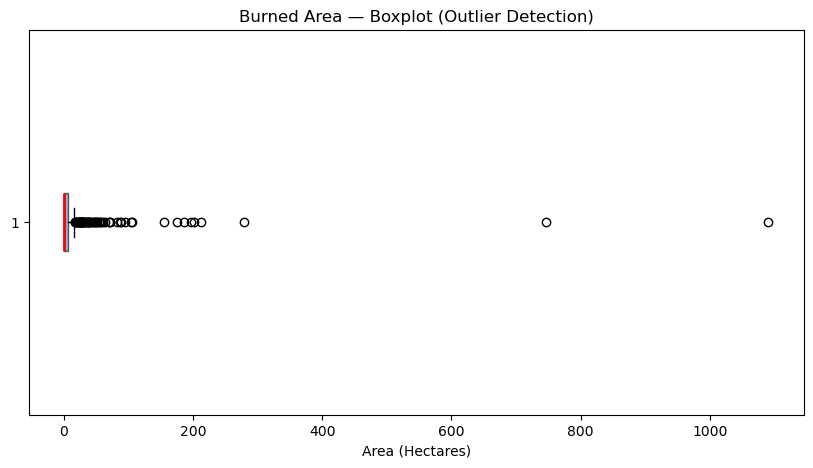

In [20]:
# Visualise outliers using boxplot
plt.figure(figsize=(10, 5))
plt.boxplot(df['area'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6),
            medianprops=dict(color='red', linewidth=2))
plt.title('Burned Area — Boxplot (Outlier Detection)')
plt.xlabel('Area (Hectares)')
plt.savefig('area_boxplot.png', dpi=150)
plt.show()

The IQR method identified several extreme outliers in the area column — fires that burned far more area than the typical event. However, these outliers are NOT removed from the dataset. They represent real catastrophic fire events that are critical to understanding wildfire severity. Removing them would bias the analysis and hide the very events we are trying to understand and predict. Instead, the log transformation in the next step handles their extreme influence mathematically.

Burned Area Statistics (Original)
count     513.00
mean       12.89
std        63.89
min         0.00
25%         0.00
50%         0.54
75%         6.57
max      1090.84
Name: area, dtype: float64

Fires with 0 area:    244 (47.6%)
Fires above 100ha:    11 (2.1%)
Fires above 500ha:    2 (0.4%)


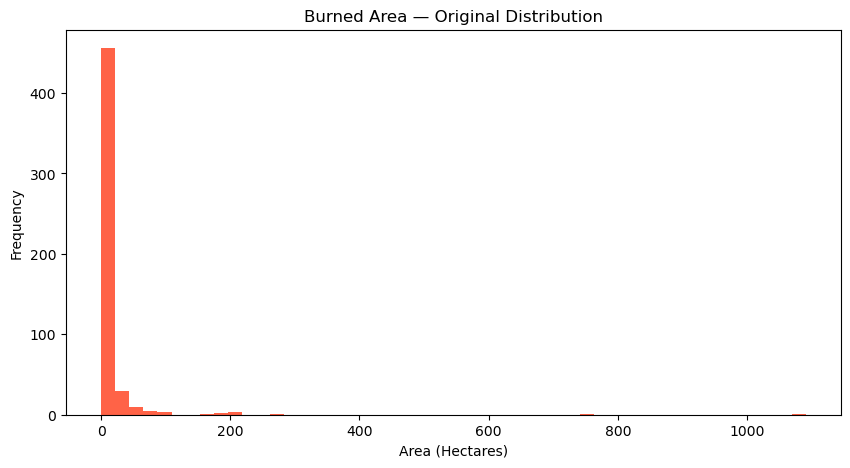

In [21]:
# First look at the raw area column before any transformation
print("Burned Area Statistics (Original)")
print(df['area'].describe().round(2))

print(f"\nFires with 0 area:    {(df['area'] == 0).sum()} ({(df['area'] == 0).mean()*100:.1f}%)")
print(f"Fires above 100ha:    {(df['area'] > 100).sum()} ({(df['area'] > 100).mean()*100:.1f}%)")
print(f"Fires above 500ha:    {(df['area'] > 500).sum()} ({(df['area'] > 500).mean()*100:.1f}%)")

# Visualise original distribution
plt.figure(figsize=(10, 5))
plt.hist(df['area'], bins=50, color='tomato')
plt.title('Burned Area — Original Distribution')
plt.xlabel('Area (Hectares)')
plt.ylabel('Frequency')
plt.savefig('area_original.png', dpi=150)
plt.show()

The original area distribution is extremely right-skewed. The majority of fires cluster near zero while a small number of catastrophic fires extend beyond 500 hectares.

Log Transformed Area Statistics
count    513.00
mean       1.11
std        1.40
min        0.00
25%        0.00
50%        0.43
75%        2.02
max        7.00
Name: log_area, dtype: float64


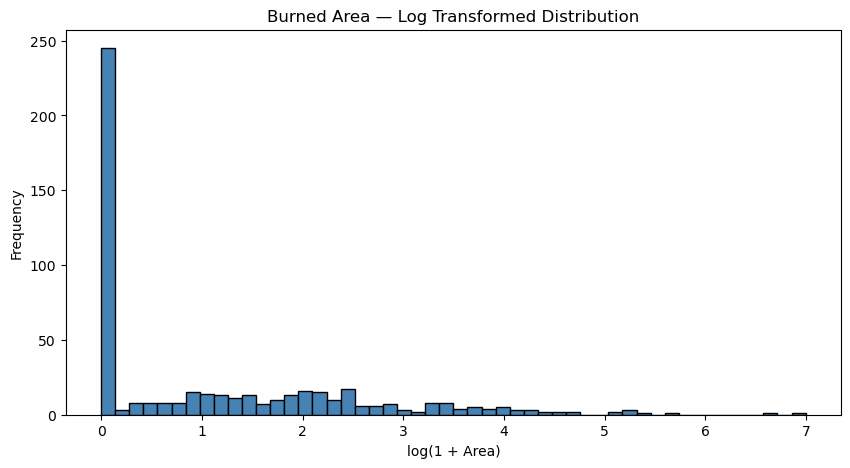

In [22]:
#TRANSFORMING THE AREA
# Apply log transformation to area
df['log_area'] = np.log1p(df['area'])

print("Log Transformed Area Statistics")
print(df['log_area'].describe().round(2))

# Visualise log-transformed distribution
plt.figure(figsize=(10, 5))
plt.hist(df['log_area'], bins=50, color='steelblue', edgecolor='black')
plt.title('Burned Area — Log Transformed Distribution')
plt.xlabel('log(1 + Area)')
plt.ylabel('Frequency')
plt.savefig('area_log_transformed.png', dpi=150)
plt.show()

After applying log1p(), the distribution becomes far more balanced and closer to normal, making it suitable for modeling. The zeros are preserved as 0.0 since log1p(0) = 0, and no data is lost in the transformation process. 

In [23]:
# Save final dataset including log_area
df.to_csv('forestfires_clean.csv', index=False)

print("Final Clean Dataset Summary")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nDataset saved as 'forestfires2_clean.csv'")

Final Clean Dataset Summary
Shape: (513, 16)
Columns: ['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area', 'month_num', 'day_num', 'log_area']

Dataset saved as 'forestfires2_clean.csv'


Exploratory Data Analysis (EDA) 

In [24]:
# Simple drought index: high temp + low humidity combined into one score
# Higher score = drier and hotter = more dangerous

df['drought_index'] = df['temp'] / (df['RH'] + 1)  # +1 avoids division by zero

print("Drought Index Statistics:")
print(df['drought_index'].describe())

Drought Index Statistics:
count    513.000000
mean       0.494685
std        0.274664
min        0.036667
25%        0.293056
50%        0.443182
75%        0.632500
max        1.540000
Name: drought_index, dtype: float64


Temperature and humidity individually tell part of the story, but separately they don't capture the full picture of how dangerous conditions are. A temperature of 30°C means very different things depending on whether humidity is 20% or 80%.
So we created a single combined score called the Drought Index. The formula is simply temperature divided by humidity. When temperature is high and humidity is low at the same time, the score shoots up, capturing exactly the conditions where fires ignite and spread most aggressively.
Looking at the statistics, the average drought index across all fire events was 0.49 — moderate conditions. But some events reached as high as 1.54, meaning the environment was extremely hot and dry simultaneously. Later in the analysis, we use 0.6 as our high-risk threshold, and you can see from this summary that 75% of fires sat below that line, meaning the top 25% of conditions were the truly dangerous ones.

In [25]:
# Make sure log_area and drought_index exist
df['log_area'] = np.log1p(df['area'])
df['drought_index'] = df['temp'] / (df['RH'] + 1)

print(f"log_area range: {df['log_area'].min():.2f} to {df['log_area'].max():.2f}")
print(f"drought_index range: {df['drought_index'].min():.2f} to {df['drought_index'].max():.2f}")

log_area range: 0.00 to 7.00
drought_index range: 0.04 to 1.54


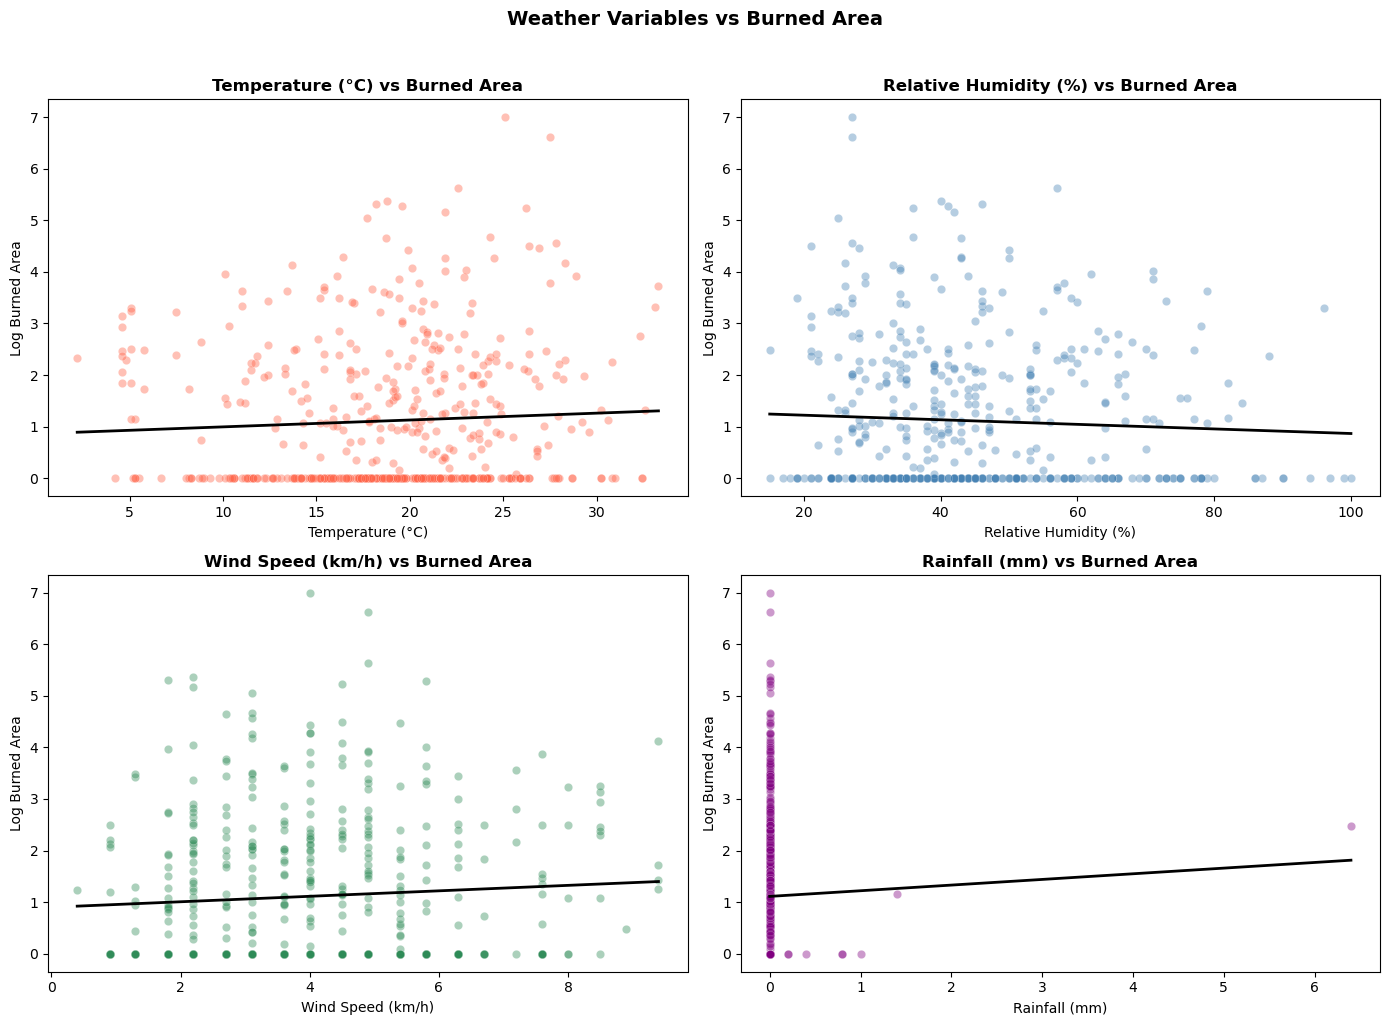

In [26]:
direct_vars = ['temp', 'RH', 'wind', 'rain']
colors = ['tomato', 'steelblue', 'seagreen', 'purple']
labels = ['Temperature (°C)', 'Relative Humidity (%)', 
          'Wind Speed (km/h)', 'Rainfall (mm)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (var, color, label) in enumerate(zip(direct_vars, colors, labels)):
    ax = axes[i//2][i%2]
    
    # Scatter plot
    ax.scatter(df[var], df['log_area'], 
               alpha=0.4, color=color, edgecolors='white', linewidth=0.3)
    
    # Trend line
    z = np.polyfit(df[var], df['log_area'], 1)
    p = np.poly1d(z)
    x_sorted = sorted(df[var])
    ax.plot(x_sorted, p(x_sorted), color='black', 
            linewidth=2, linestyle='-')
    
    # Labels
    ax.set_title(f'{label} vs Burned Area', fontsize=12, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Log Burned Area')

plt.suptitle('Weather Variables vs Burned Area', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('weather_vs_area.png', dpi=150)
plt.show()

1. Temperature has a weak positive relationship with burned area. As temperature increases, burned area tends to increase slightly, but the relationship is not strong enough to predict fire size on its own. The concentration of fires between 10 and 25°C confirms that this is the most active temperature range in the dataset rather than extreme heat.
2. Large fires appear across all humidity levels, not just low humidity. Humidity shows a weak negative relationship with burned area; as humidity increases, burned area tends to decrease slightly. However, the relationship is very weak, suggesting that humidity alone cannot determine fire severity. Large fires occurred even at relatively high humidity levels, confirming that multiple conditions must combine to produce severe fires.
3. Wind speed shows a moderate positive relationship with burned area — the clearest trend among the four weather variables. Higher wind speeds are associated with larger fires, which aligns with the real-world understanding that wind spreads flames, dries out vegetation ahead of the fire, and supplies oxygen to increase fire intensity.
4. Rainfall has almost no meaningful relationship with burned area in this dataset. Over 94% of all fire events occurred with zero recorded rainfall, meaning the variable has almost no variation to analyze.

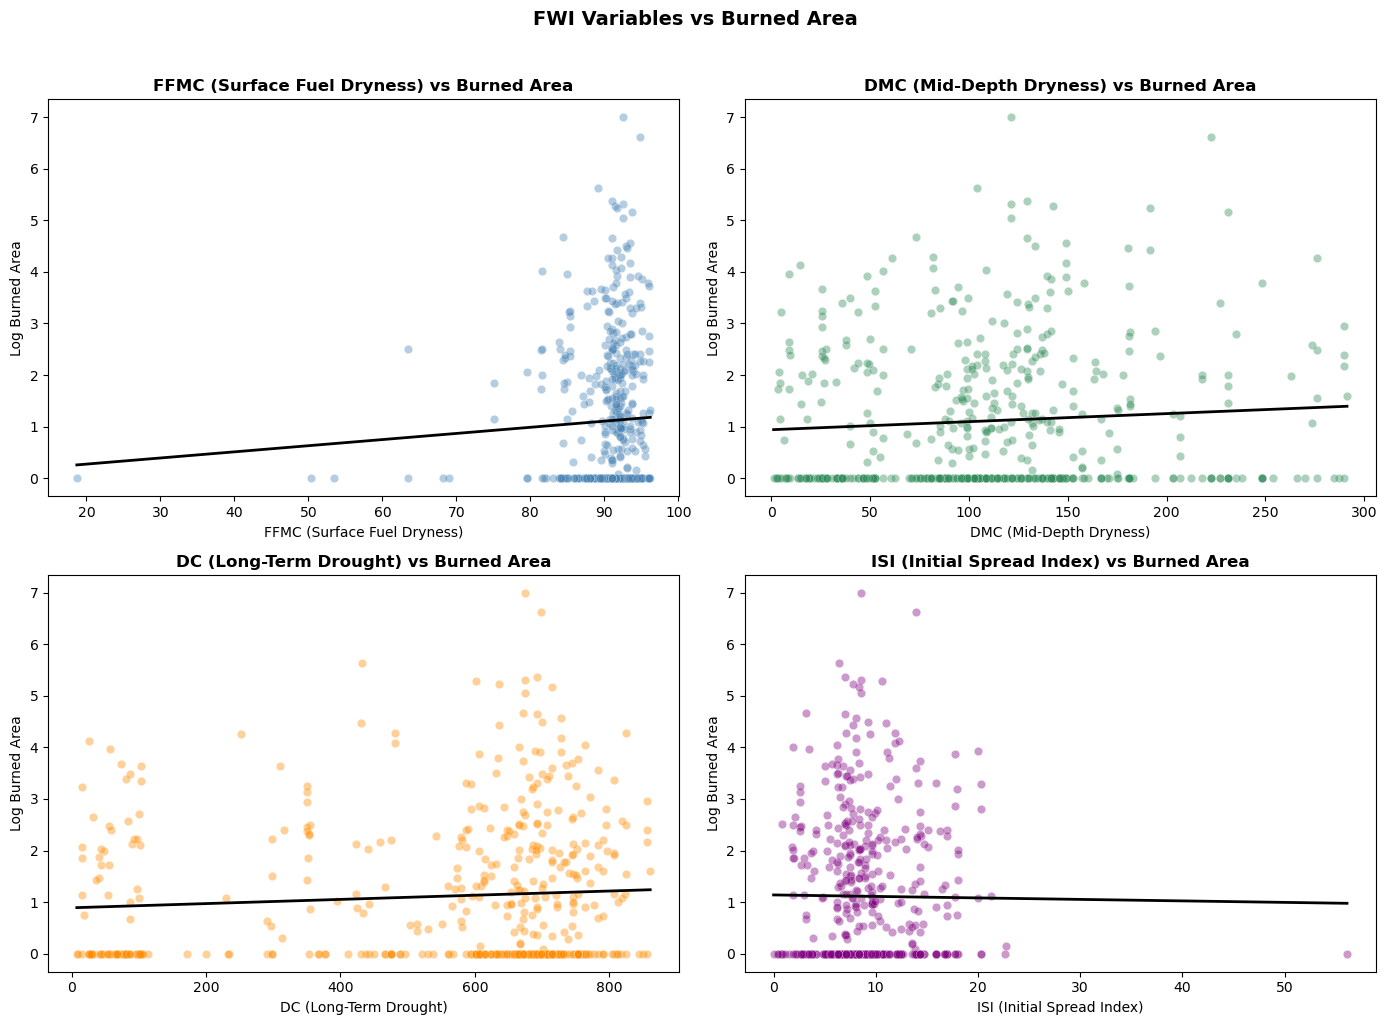

In [27]:
fwi_vars = ['FFMC', 'DMC', 'DC', 'ISI']
fwi_colors = ['steelblue', 'seagreen', 'darkorange', 'purple']
fwi_labels = ['FFMC (Surface Fuel Dryness)', 
               'DMC (Mid-Depth Dryness)',
               'DC (Long-Term Drought)', 
               'ISI (Initial Spread Index)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (var, color, label) in enumerate(zip(fwi_vars, fwi_colors, fwi_labels)):
    ax = axes[i//2][i%2]
    
    ax.scatter(df[var], df['log_area'],
               alpha=0.4, color=color, edgecolors='white', linewidth=0.3)
    
    z = np.polyfit(df[var], df['log_area'], 1)
    p = np.poly1d(z)
    x_sorted = sorted(df[var])
    ax.plot(x_sorted, p(x_sorted), color='black',
            linewidth=2, linestyle='-')
    
    ax.set_title(f'{label} vs Burned Area', fontsize=12, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Log Burned Area')

plt.suptitle('FWI Variables vs Burned Area',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fwi_vs_area.png', dpi=150)
plt.show()

1. FFMC shows a clear threshold effect rather than a gradual relationship. Almost no fires occurred when FFMC was below 70, confirming that surface fuel must reach a critical dryness level before fires can start and spread. Above 80, fires become increasingly common and increasingly severe.
2. DMC shows a weak positive relationship with burned area. As mid-depth organic material becomes drier, fires tend to burn slightly larger areas, but the relationship is not strong or consistent. Unlike FFMC, there is no clear threshold; fires of all sizes occurred across the full DMC range. This suggests DMC contributes to sustained burning depth rather than determining whether a large fire occurs.
3. DC shows the most consistent positive trend among the FWI variables. As long-term drought accumulates, fires tend to burn larger areas. The widespread nature of the data reflects the fact that DC builds over months; fires recorded early in the season have low DC, while fires in August and September have very high DC.
4. ISI shows almost no linear relationship with burned area, the flattest trend line among all FWI variables. This is surprising since ISI measures how fast a fire spreads initially. However, the explanation lies in the extreme outliers, a few events with very high ISI values (30—56) actually produced small burned areas, pulling the trend line flat.

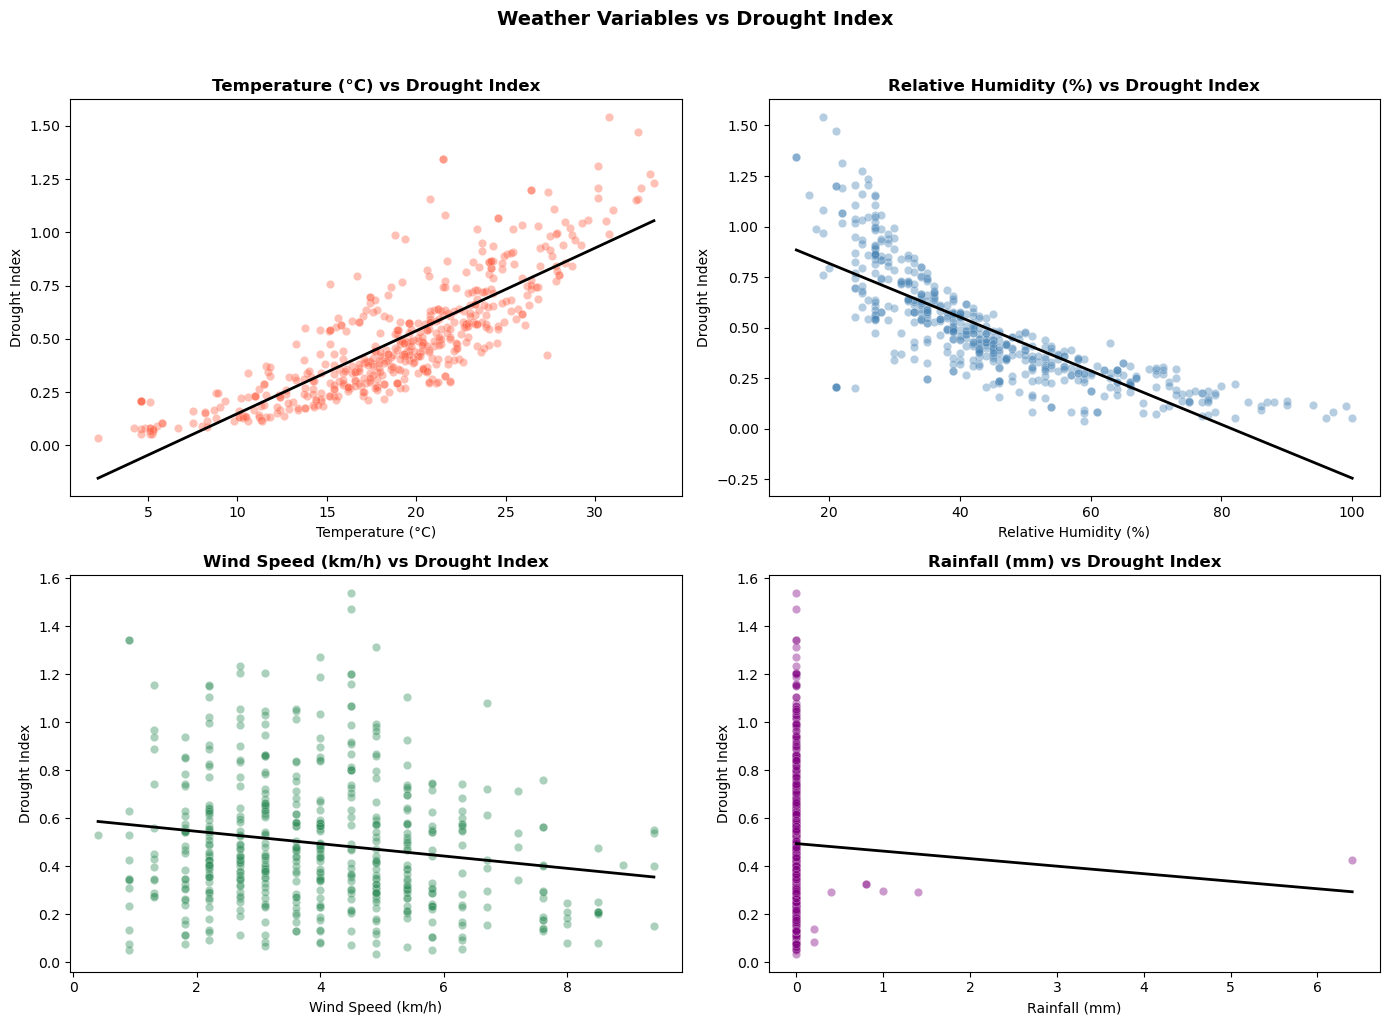

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (var, color, label) in enumerate(zip(direct_vars, colors, labels)):
    ax = axes[i//2][i%2]
    
    ax.scatter(df[var], df['drought_index'],
               alpha=0.4, color=color, edgecolors='white', linewidth=0.3)
    
    z = np.polyfit(df[var], df['drought_index'], 1)
    p = np.poly1d(z)
    x_sorted = sorted(df[var])
    ax.plot(x_sorted, p(x_sorted), color='black',
            linewidth=2, linestyle='-')
    
    ax.set_title(f'{label} vs Drought Index', fontsize=12, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Drought Index')

plt.suptitle('Weather Variables vs Drought Index',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('weather_vs_drought.png', dpi=150)
plt.show()

1. Temperature has the strongest and most consistent positive relationship with drought index of any variable in the dataset. As temperature rises the drought index rises almost proportionally — confirming that heat is the primary driver of dangerous drought conditions.
2. Relative humidity has the strongest negative relationship with drought index of any variable in the dataset. As humidity increases the drought index falls sharply and consistently — confirming that atmospheric moisture is the primary suppressor of dangerous drought conditions.
3. Wind speed shows a negative relationship with drought index — as wind speed increases the drought index tends to decrease. This is counterintuitive at first glance since wind is associated with fire danger. However it makes perfect sense when you understand what drought index measures.
4. Rainfall shows a negative relationship with drought index as expected — days with recorded rainfall tend to have lower drought index values.

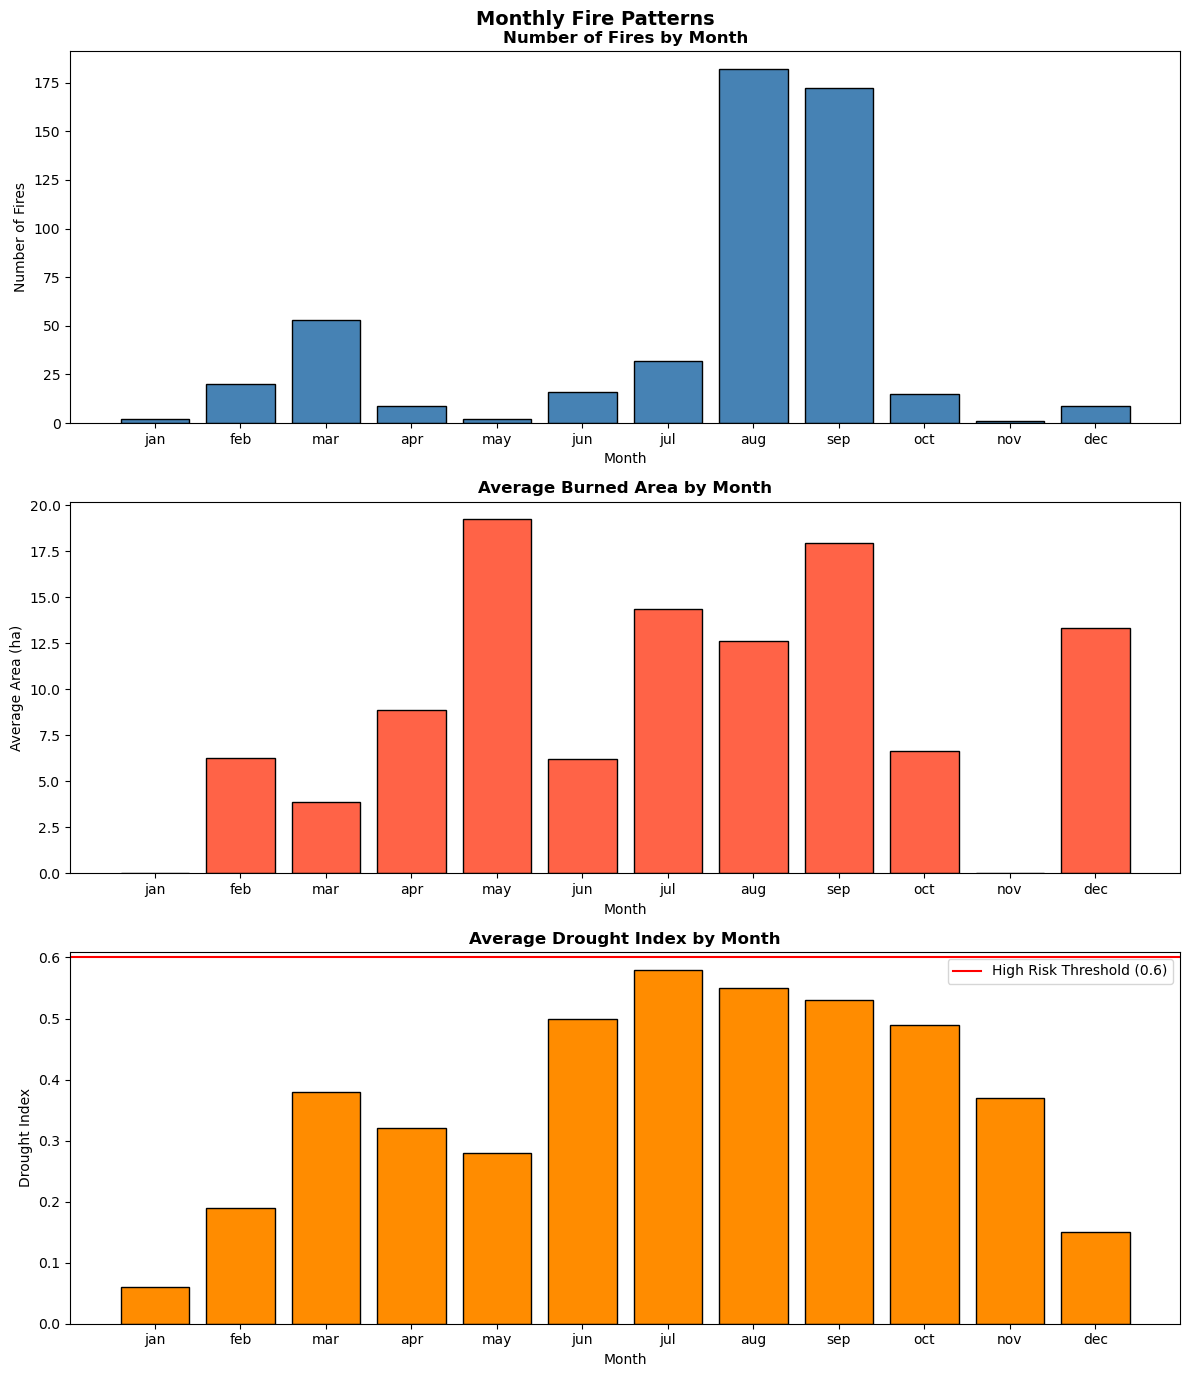

Monthly Summary
month  fire_count  avg_area  avg_drought
  jan           2      0.00         0.06
  feb          20      6.28         0.19
  mar          53      3.90         0.38
  apr           9      8.89         0.32
  may           2     19.24         0.28
  jun          16      6.21         0.50
  jul          32     14.37         0.58
  aug         182     12.63         0.55
  sep         172     17.94         0.53
  oct          15      6.64         0.49
  nov           1      0.00         0.37
  dec           9     13.33         0.15


In [29]:
# Count and average area by month
monthly = df.groupby('month', observed=True).agg(
    fire_count=('area', 'count'),
    avg_area=('area', 'mean'),
    avg_drought=('drought_index', 'mean')
).round(2).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# Chart 1 — Number of fires per month
axes[0].bar(monthly['month'].astype(str), monthly['fire_count'],
            color='steelblue', edgecolor='black')
axes[0].set_title('Number of Fires by Month', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Fires')

# Chart 2 — Average burned area per month
axes[1].bar(monthly['month'].astype(str), monthly['avg_area'],
            color='tomato', edgecolor='black')
axes[1].set_title('Average Burned Area by Month', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Area (ha)')

# Chart 3 — Average drought index per month
axes[2].bar(monthly['month'].astype(str), monthly['avg_drought'],
            color='darkorange', edgecolor='black')
axes[2].axhline(y=0.6, color='red', linestyle='-', 
                linewidth=1.5, label='High Risk Threshold (0.6)')
axes[2].set_title('Average Drought Index by Month', fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Drought Index')
axes[2].legend()

plt.suptitle('Monthly Fire Patterns', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('monthly_patterns.png', dpi=150)
plt.show()

print("Monthly Summary")
print(monthly.to_string(index=False))

1. August and September together account for the overwhelming majority of all fire events. The difference is not subtle; August alone had 182 fires, while January had just 2. This is the clearest evidence we have for why fire resources need to be concentrated in those two months.
2. May's average is high because it is based on only 2 fires. A single large fire inflates the average. September's average of 17.94 ha is based on 172 fires, meaning fires were large consistently, not just once.
3. This third chart explains WHY August and September are so dangerous. The drought index — our combined temperature and humidity score — peaks in July and stays elevated through September. The red line marks our high-risk threshold of 0.6. July almost crosses it, and August and September stay just below it.

In [30]:
# Average of all variables by month
monthly_full = df.groupby('month', observed=True).agg(
    fire_count=('area', 'count'),
    avg_temp=('temp', 'mean'),
    avg_RH=('RH', 'mean'),
    avg_wind=('wind', 'mean'),
    avg_rain=('rain', 'mean'),
    avg_FFMC=('FFMC', 'mean'),
    avg_DMC=('DMC', 'mean'),
    avg_DC=('DC', 'mean'),
    avg_ISI=('ISI', 'mean'),
    avg_area=('area', 'mean'),
    avg_drought=('drought_index', 'mean')
).round(2)

# Rename columns for clarity
monthly_full.columns = [
    'Fire Count', 'Avg Temp (°C)', 'Avg Humidity (%)', 
    'Avg Wind (km/h)', 'Avg Rain (mm)', 'Avg FFMC', 
    'Avg DMC', 'Avg DC', 'Avg ISI', 
    'Avg Area (ha)', 'Avg Drought Index'
]

print("Monthly Summary — All Variables")
print(monthly_full.to_string())

Monthly Summary — All Variables
       Fire Count  Avg Temp (°C)  Avg Humidity (%)  Avg Wind (km/h)  Avg Rain (mm)  Avg FFMC  Avg DMC  Avg DC  Avg ISI  Avg Area (ha)  Avg Drought Index
month                                                                                                                                                   
jan             2           5.25             89.00             2.00           0.00     50.40     2.40   90.35     1.45           0.00               0.06
feb            20           9.64             55.70             3.76           0.00     82.90     9.48   54.67     3.35           6.28               0.19
mar            53          13.01             40.25             4.97           0.00     89.40    34.52   75.85     7.09           3.90               0.38
apr             9          12.04             46.89             4.67           0.00     85.79    15.91   48.56     5.38           8.89               0.32
may             2          14.65             67.00

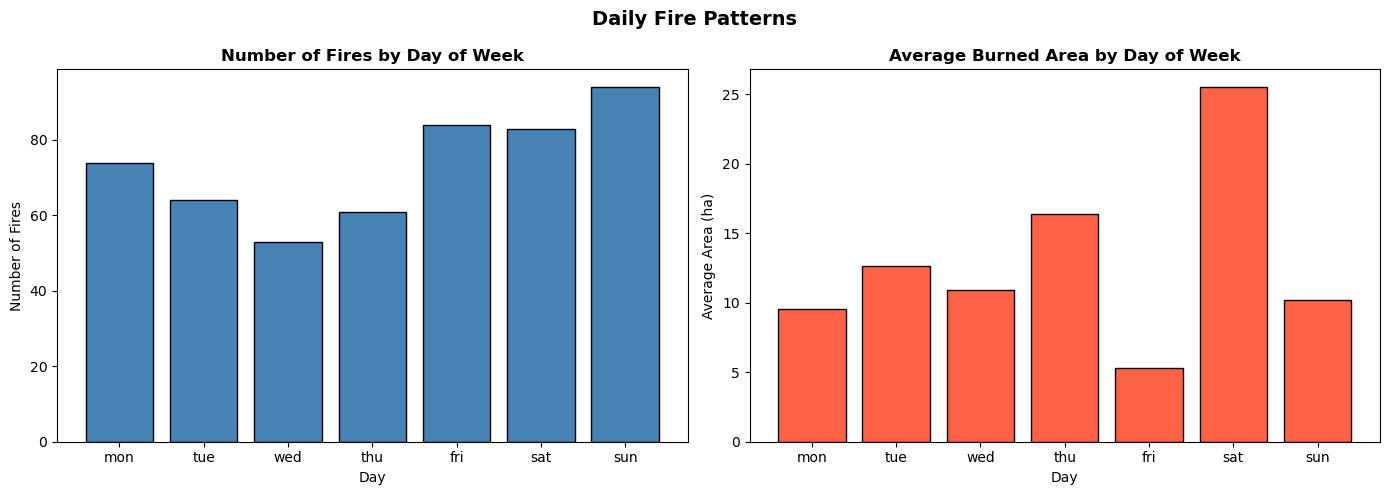

Daily Summary
day  fire_count  avg_area  avg_drought
mon          74      9.55         0.43
tue          64     12.62         0.51
wed          53     10.92         0.59
thu          61     16.35         0.60
fri          84      5.32         0.44
sat          83     25.50         0.51
sun          94     10.21         0.45


In [31]:
daily = df.groupby('day', observed=True).agg(
    fire_count=('area', 'count'),
    avg_area=('area', 'mean'),
    avg_drought=('drought_index', 'mean')
).round(2).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Number of fires by day
axes[0].bar(daily['day'].astype(str), daily['fire_count'],
            color='steelblue', edgecolor='black')
axes[0].set_title('Number of Fires by Day of Week', fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Number of Fires')

# Average burned area by day
axes[1].bar(daily['day'].astype(str), daily['avg_area'],
            color='tomato', edgecolor='black')
axes[1].set_title('Average Burned Area by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Average Area (ha)')

plt.suptitle('Daily Fire Patterns', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('daily_patterns.png', dpi=150)
plt.show()

print("Daily Summary")
print(daily.to_string(index=False))

FEATURE ENGINEERING 

In [32]:
# DROUGHT INDEX
# Formula: Temperature divided by (Humidity + 1)

df['drought_index'] = df['temp'] / (df['RH'] + 1)

print("Drought Index Created")
print(df['drought_index'].describe().round(1))
print(f"\nSample values:")
print(df[['temp', 'RH', 'drought_index']].head(10))

Drought Index Created
count    513.0
mean       0.5
std        0.3
min        0.0
25%        0.3
50%        0.4
75%        0.6
max        1.5
Name: drought_index, dtype: float64

Sample values:
   temp  RH  drought_index
0   8.2  51       0.157692
1  18.0  33       0.529412
2  14.6  33       0.429412
3   8.3  97       0.084694
4  11.4  99       0.114000
5  22.2  29       0.740000
6  24.1  27       0.860714
7   8.0  86       0.091954
8  13.1  63       0.204687
9  22.8  40       0.556098


The Drought Index turns two separate variables — temperature and humidity — into one risk score that the model can use directly. Instead of the model having to figure out on its own that high temp AND low humidity together are dangerous, you handed it directly. This is exactly what we want the index to do — compress two separate variables into one number that instantly tells us how dangerous conditions are. We don't need to look at temperature and humidity separately. They just check if the drought index is above 0.6 and act accordingly.

In [33]:
# HIGH RISK CONDITIONS
# 1 = High Risk, 0 = Normal
# High risk defined as: temperature above 25°C AND humidity below 30%

df['high_risk'] = ((df['temp'] > 25) & (df['RH'] < 30)).astype(int)

print("High Risk Conditions Created")
print(df['high_risk'].value_counts())
print(f"\nPercentage of high risk fires: {df['high_risk'].mean() * 100:.1f}%")

# Compare burned area under high risk vs normal
risk_comparison = df.groupby('high_risk')['area'].agg(['mean', 'count', 'sum']).round(2)
risk_comparison.index = ['Normal Conditions', 'High Risk Conditions']
risk_comparison.columns = ['Avg Area (ha)', 'Fire Count', 'Total Area (ha)']
print(f"\nImpact of High Risk Conditions")
print(risk_comparison)

High Risk Conditions Created
high_risk
0    477
1     36
Name: count, dtype: int64

Percentage of high risk fires: 7.0%

Impact of High Risk Conditions
                      Avg Area (ha)  Fire Count  Total Area (ha)
Normal Conditions              8.89         477          4240.10
High Risk Conditions          65.92          36          2373.29


Just 36 fires, only 7% of all fire events, occurred under high-risk conditions. But those 36 fires burned an average of 65.92 hectares each. Compare that to normal conditions where the average is just 8.89 hectares.
That means high-risk fires burned 7.4 times more area than normal fires on average.
Even more striking, those 36 fires alone accounted for 2,373 hectares of total burned area. The remaining 477 normal fires together burned 4,240 hectares. So 7% of fires caused 36% of all destruction. 

Fire Size Category Created
fire_size
Small    419
Large     94
Name: count, dtype: int64

Percentage breakdown:
fire_size
Small    81.7
Large    18.3
Name: count, dtype: float64


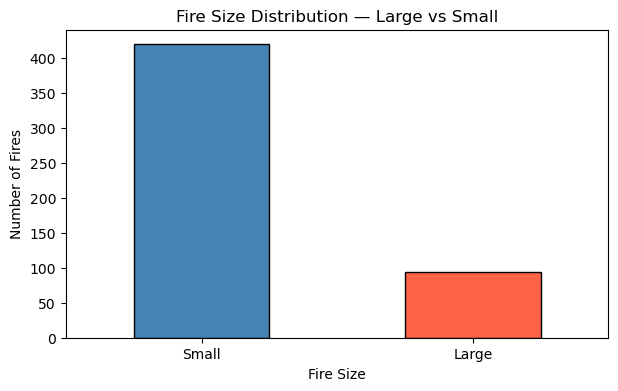

In [34]:
# FIRE SIZE CATEGORY
# Small = area <= 10 ha (manageable fires)
# Large = area > 10 ha (destructive fires requiring major response)

df['fire_size'] = pd.cut(df['area'],
                          bins=[-1, 10, df['area'].max()],
                          labels=['Small', 'Large'])

print("Fire Size Category Created")
print(df['fire_size'].value_counts())
print(f"\nPercentage breakdown:")
print((df['fire_size'].value_counts() / len(df) * 100).round(1))

# Visualise
plt.figure(figsize=(7, 4))
df['fire_size'].value_counts().plot(
    kind='bar',
    color=['steelblue', 'tomato'],
    edgecolor='black'
)
plt.title('Fire Size Distribution — Large vs Small')
plt.xlabel('Fire Size')
plt.ylabel('Number of Fires')
plt.xticks(rotation=0)
plt.savefig('fire_size_distribution.png', dpi=150)
plt.show()

This chart shows one of the most important realities of wildfire data — the vast majority of fires stay small. 81.7% of all fire events in this dataset burned 10 hectares or less. Only 18.3% — roughly 1 in 5 fires — grew large enough to be classified as destructive.
The blue bar representing small fires is more than four times taller than the red bar for large fires. At first glance this might seem reassuring — but it is actually the opposite of reassuring. It means that when conditions do allow a fire to escape the small category, something has gone seriously wrong environmentally.
This is also why we used this column as the target variable for classification modelling. Instead of asking 'exactly how many hectares will burn' — which is very hard to predict precisely — we can ask the simpler but more actionable question: will this fire stay small or become large? That binary prediction is more useful for emergency response planning.

Season Column Created
season
Summer    230
Autumn    188
Spring     64
Winter     31
Name: count, dtype: int64

Fire Activity by Season
        Fire Count  Avg Area (ha)  Total Area (ha)
season                                            
Winter          31           7.92           245.47
Spring          64           5.08           325.10
Summer         230          12.42          2857.12
Autumn         188          16.95          3185.70


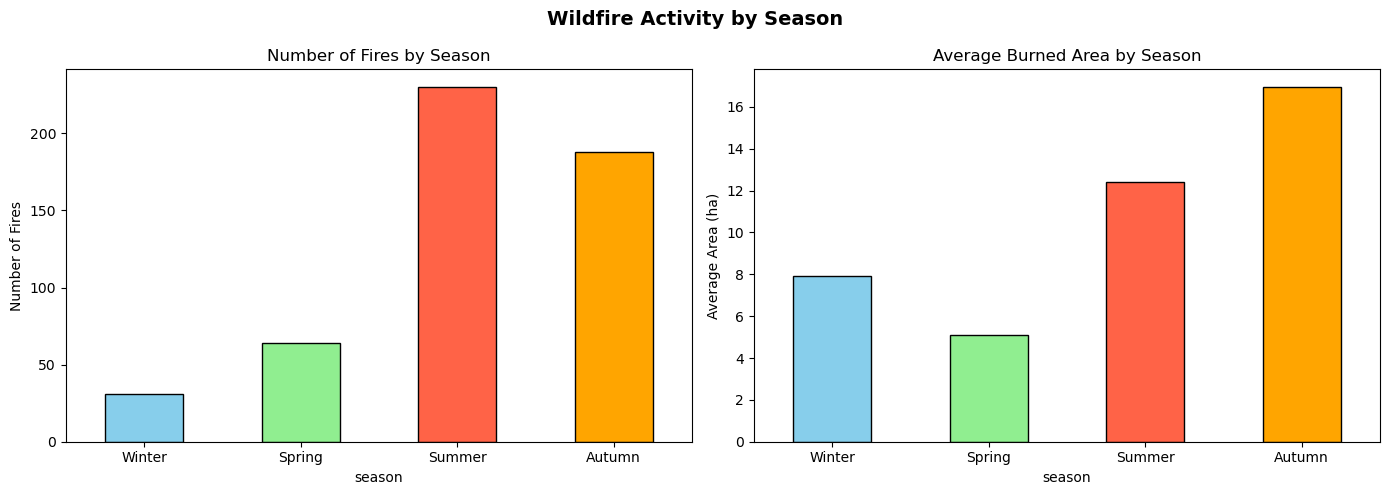

In [35]:
# SEASON
# Groups months into four seasons for clearer pattern analysis

def get_season(month):
    if month in ['dec', 'jan', 'feb']:
        return 'Winter'
    elif month in ['mar', 'apr', 'may']:
        return 'Spring'
    elif month in ['jun', 'jul', 'aug']:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['month'].astype(str).apply(get_season)

print("Season Column Created")
print(df['season'].value_counts())

# Visualise fires by season
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_data = df.groupby('season')['area'].agg(['count', 'mean', 'sum']).round(2)
season_data = season_data.reindex(season_order)
season_data.columns = ['Fire Count', 'Avg Area (ha)', 'Total Area (ha)']

print(f"\nFire Activity by Season")
print(season_data)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fire count
season_data['Fire Count'].plot(
    kind='bar', ax=axes[0],
    color=['skyblue', 'lightgreen', 'tomato', 'orange'],
    edgecolor='black'
)
axes[0].set_title('Number of Fires by Season')
axes[0].set_ylabel('Number of Fires')
axes[0].tick_params(axis='x', rotation=0)

# Average area
season_data['Avg Area (ha)'].plot(
    kind='bar', ax=axes[1],
    color=['skyblue', 'lightgreen', 'tomato', 'orange'],
    edgecolor='black'
)
axes[1].set_title('Average Burned Area by Season')
axes[1].set_ylabel('Average Area (ha)')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Wildfire Activity by Season', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fires_by_season.png', dpi=150)
plt.show()

Grouping by season gives us a cleaner, higher-level view of fire patterns that is easier to communicate to decision makers than looking at 12 individual months.
The left chart shows Summer dominates fire frequency — with around 230 fires, it dwarfs Winter and Spring combined. This is driven almost entirely by August, which had 182 fires on its own.
But the right chart tells a more nuanced story. Autumn has the highest average burned area at around 17 hectares — higher than Summer's 12 hectares. This is because September, which falls in Autumn, combines still-elevated temperatures with the highest DC values of the entire year at 734. The land has been drying out all summer and by September the deep soil drought is at its absolute worst.
So Summer is when fires are most frequent — but Autumn is when they are most destructive. For resource planning, this means you need maximum staffing in Summer to handle volume, and maximum heavy response capability in Autumn to handle severity.

Drought Level Created
drought_level
Moderate     232
Safe         135
High         116
Dangerous     30
Name: count, dtype: int64

Percentage breakdown:
drought_level
Moderate     45.2
Safe         26.3
High         22.6
Dangerous     5.8
Name: count, dtype: float64

Burned Area by Drought Level
               Avg Burned Area (ha)  Fire Count
drought_level                                  
Safe                           6.11         135
Moderate                      10.76         232
High                          25.95         116
Dangerous                      9.42          30


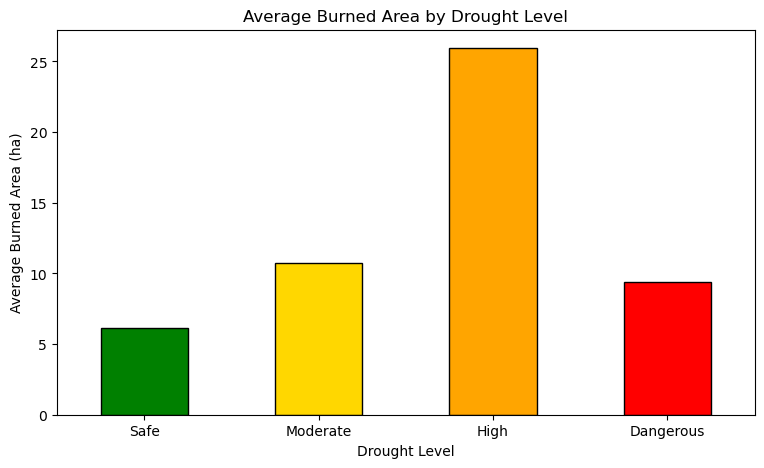

In [36]:
# DROUGHT LEVEL
# Categorise the continuous drought index into four risk levels

bins = [0, 0.3, 0.6, 1.0, df['drought_index'].max()]
labels = ['Safe', 'Moderate', 'High', 'Dangerous']

df['drought_level'] = pd.cut(df['drought_index'],
                              bins=bins,
                              labels=labels)

print("Drought Level Created")
print(df['drought_level'].value_counts())
print(f"\nPercentage breakdown:")
print((df['drought_level'].value_counts() / len(df) * 100).round(1))

# Average burned area by drought level
drought_analysis = df.groupby('drought_level', observed=True)['area'].agg(
    ['mean', 'count']
).round(2)
drought_analysis.columns = ['Avg Burned Area (ha)', 'Fire Count']

print(f"\nBurned Area by Drought Level")
print(drought_analysis)

# Visualise
plt.figure(figsize=(9, 5))
drought_analysis['Avg Burned Area (ha)'].plot(
    kind='bar',
    color=['green', 'gold', 'orange', 'red'],
    edgecolor='black'
)
plt.title('Average Burned Area by Drought Level')
plt.xlabel('Drought Level')
plt.ylabel('Average Burned Area (ha)')
plt.xticks(rotation=0)
plt.savefig('drought_level_vs_area.png', dpi=150)
plt.show()

This chart shows how average burned area changes as drought conditions worsen — and it tells a clear story up to a point.
Moving from Safe to Moderate to High, the average burned area rises consistently — from 6 hectares to 10 hectares to 26 hectares. That is the pattern we expected — drier conditions producing bigger fires.

Temperature Band Created
temp_band
0-10°C      36
10-15°C     77
15-20°C    170
20-25°C    165
25+°C       65
Name: count, dtype: int64

Burned Area by Temperature Band
           Avg Burned Area (ha)  Fire Count
temp_band                                  
0-10°C                     6.42          36
10-15°C                    5.24          77
15-20°C                   10.32         170
20-25°C                    9.44         165
25+°C                     41.03          65


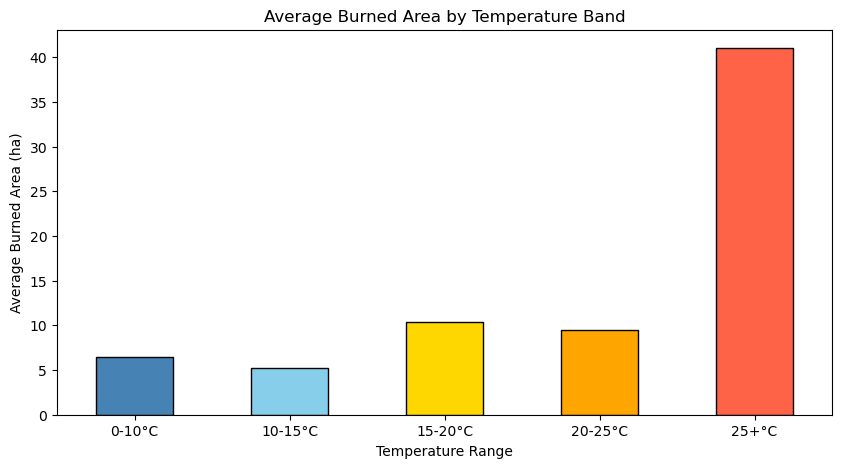

In [37]:
# TEMPERATURE BAND
# Allows analysis of fire severity at different temperature thresholds
# Helps identify the temperature at which fire risk increases significantly

df['temp_band'] = pd.cut(df['temp'],
                          bins=[0, 10, 15, 20, 25, 35],
                          labels=['0-10°C', '10-15°C', 
                                  '15-20°C', '20-25°C', '25+°C'])

print("Temperature Band Created")
print(df['temp_band'].value_counts().sort_index())

# Average burned area by temperature band
temp_analysis = df.groupby('temp_band', observed=True)['area'].agg(
    ['mean', 'count']
).round(2)
temp_analysis.columns = ['Avg Burned Area (ha)', 'Fire Count']

print(f"\nBurned Area by Temperature Band")
print(temp_analysis)

# Visualise
plt.figure(figsize=(10, 5))
temp_analysis['Avg Burned Area (ha)'].plot(
    kind='bar',
    color=['steelblue', 'skyblue', 'gold', 'orange', 'tomato'],
    edgecolor='black'
)
plt.title('Average Burned Area by Temperature Band')
plt.xlabel('Temperature Range')
plt.ylabel('Average Burned Area (ha)')
plt.xticks(rotation=0)
plt.savefig('temp_band_vs_area.png', dpi=150)
plt.show()

From 0°C all the way up to 25°C, average burned area stays relatively flat — hovering between 5 and 10 hectares across all four lower bands. There is no dramatic difference between a fire at 8°C and a fire at 22°C in terms of how much land it burns.
But the moment temperature crosses 25°C — everything changes. The average burned area jumps to 41 hectares. That is four times higher than any other temperature band. This is not a gradual increase — it is a sharp cliff edge.
This finding directly validates the threshold we used to define high risk conditions earlier. We set the high risk flag at temperature above 25°C combined with humidity below 30% — and this chart confirms that 25°C is exactly where fire destructiveness escalates dramatically.

In [38]:
# Confirm all new features were created successfully
print("All Engineered Features")
new_features = ['drought_index', 'high_risk', 'fire_size', 
                'season', 'drought_level', 'temp_band']

for feature in new_features:
    print(f"\n{feature}:")
    print(df[feature].value_counts())

# Preview all new columns together
print("\nSample of Engineered Dataset")
print(df[['temp', 'RH', 'area', 'drought_index', 
          'high_risk', 'fire_size', 'season', 
          'drought_level', 'temp_band']].head(10))

# Save updated dataset
df.to_csv('forestfires_engineered2.csv', index=False)
print("\nEngineered dataset saved as 'forestfires_engineered.csv'")
print(f"Total columns now: {df.shape[1]}")

All Engineered Features

drought_index:
drought_index
0.542857    4
0.209091    4
0.234043    3
0.576471    3
0.290769    3
           ..
0.502500    1
0.341176    1
0.608333    1
0.450000    1
0.368750    1
Name: count, Length: 463, dtype: int64

high_risk:
high_risk
0    477
1     36
Name: count, dtype: int64

fire_size:
fire_size
Small    419
Large     94
Name: count, dtype: int64

season:
season
Summer    230
Autumn    188
Spring     64
Winter     31
Name: count, dtype: int64

drought_level:
drought_level
Moderate     232
Safe         135
High         116
Dangerous     30
Name: count, dtype: int64

temp_band:
temp_band
15-20°C    170
20-25°C    165
10-15°C     77
25+°C       65
0-10°C      36
Name: count, dtype: int64

Sample of Engineered Dataset
   temp  RH  area  drought_index  high_risk fire_size  season drought_level  \
0   8.2  51   0.0       0.157692          0     Small  Spring          Safe   
1  18.0  33   0.0       0.529412          0     Small  Autumn      Moderate   
2

MODELLING 

In [39]:
# Import all required modelling libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

In [40]:
# Features — the variables the model learns from
features = ['temp', 'RH', 'wind', 'rain', 
            'FFMC', 'DMC', 'DC', 'ISI',
            'drought_index', 'high_risk', 
            'month_num', 'day_num']

# Target — what we want to predict
target = 'log_area'

# Create X (features) and y (target)
X = df[features]
y = df[target]

print("Features and Target Selected")
print(f"Number of features: {len(features)}")
print(f"Features: {features}")
print(f"Target: {target}")
print(f"Total samples: {len(X)}")

Features and Target Selected
Number of features: 12
Features: ['temp', 'RH', 'wind', 'rain', 'FFMC', 'DMC', 'DC', 'ISI', 'drought_index', 'high_risk', 'month_num', 'day_num']
Target: log_area
Total samples: 513


Before training any model, we have to make a clear decision — what are we giving the model to work with, and what are we asking it to figure out.
We gave the model 12 input variables — covering daily weather conditions, the four FWI fire indices, the two features we engineered ourselves, and the time variables for month and day. Together these 12 variables represent the full environmental picture at the moment each fire was recorded.
The target — what we are asking the model to predict — is log_area. That is the log-transformed version of burned area. So the model's job is: given these 12 conditions, predict how large the resulting fire will be.
Notice that we did not include fire_size, season, drought_level or temp_band as features. Those are categories we created for analysis purposes — putting them into the model would be circular, since some of them are derived from the same variables already in the feature list.

In [41]:
# Split data — 80% training, 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train/Test Split Complete")
print(f"Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing samples:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

Train/Test Split Complete
Training samples: 410 (79.9%)
Testing samples:  103 (20.1%)


Before we train the model, we split our data into two separate groups and keep them completely apart from each other.
The training set — 410 records — is what the model learns from. It studies these records, finds patterns, and builds its internal rules for predicting fire size.
The testing set — 103 records — is locked away and never shown to the model during training. Once the model has finished learning, we reveal the test set and ask the model to make predictions on fire records it has never seen before. We then compare those predictions to the real burned areas we already know. 

The random_state=42 parameter ensures the split happens the same way every time the code is run. Without it, Python would randomly assign different records to training and testing each time, making results impossible to reproduce. Setting random_state to any fixed number — 42 is a common convention in data science — locks the split so anyone running this code gets identical results. 

The 80/20 split is the standard in data science for datasets of this size. 80% gives the model enough records to learn meaningful patterns — too little training data and the model cannot learn properly. 20% gives us enough test records to evaluate performance reliably — too few test records and one or two unusual fires could make the results misleading. 


In [42]:
# Scale features to same range

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print(f"Model type: Linear Regression")
print(f"Trained on: {len(X_train)} samples")
print(f"Number of features used: {len(features)}")

Model type: Linear Regression
Trained on: 410 samples
Number of features used: 12


In [44]:
# Make predictions on test set
y_pred = model.predict(X_test_scaled)

# Calculate performance metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("Model Performance Metrics")
print(f"Mean Absolute Error  (MAE):  {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score:                    {r2:.4f}")


Model Performance Metrics
Mean Absolute Error  (MAE):  1.0896
Root Mean Squared Error (RMSE): 1.2807
R² Score:                    0.0182


MAE: This measures the average prediction error in log units.
On average, the model's prediction was 1.09 log units away from the real value. To put that in perspective — remember our log scale goes from 0 to 7. An error of 1.09 on that scale means the model is in the right ballpark but not precise.

RMSE: The RMSE of 1.28 is slightly higher than the MAE of 1.09. That gap tells us the model is making some particularly large errors on certain fires — not just consistently small errors across the board. The catastrophic fires are the hardest to predict accurately.

R²: It measures what percentage of fire size variation the model successfully explains. The model's R² of 0.018 confirms what fire science already knows — predicting exact burned area is extremely difficult, but understanding the conditions that create risk is where the real value lies.

Feature Coefficients
      Feature  Coefficient
         temp     0.352544
    month_num     0.270573
    high_risk     0.255188
         wind     0.103350
          DMC     0.080399
         rain     0.025014
         FFMC     0.006721
      day_num    -0.019761
          ISI    -0.075987
           RH    -0.212061
           DC    -0.238773
drought_index    -0.543945

Positive = increases burned area
Negative = decreases burned area
Larger value = stronger influence


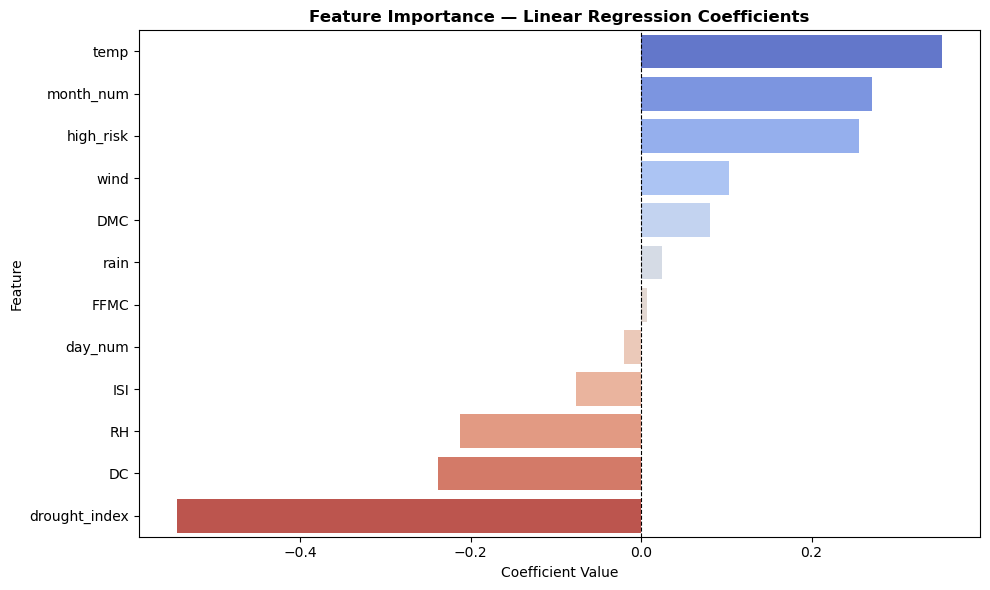

In [45]:
# Show which features influence predictions most
importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print("Feature Coefficients")
print(importance.to_string(index=False))
print("\nPositive = increases burned area")
print("Negative = decreases burned area")
print("Larger value = stronger influence")

# Visualise
plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x='Coefficient', y='Feature',
            hue='Feature', palette='coolwarm', legend=False)
plt.title('Feature Importance — Linear Regression Coefficients',
          fontweight='bold')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('regression_feature_importance.png', dpi=150)
plt.show()

Once the model finished training, we extracted its coefficients — essentially the model's own opinion on which variables matter most and in which direction.
Temperature comes out as the strongest positive driver at 0.353 — the model learned that hotter conditions are associated with larger fires. Month number at 0.271 confirms the seasonal pattern we found in EDA — later months tend to produce bigger fires. The high risk flag at 0.255 validates our feature engineering decision — creating that variable gave the model a useful signal.
On the negative side, drought_index has the largest coefficient of all at -0.544. This seems counterintuitive at first — shouldn't higher drought mean bigger fires? But remember that drought_index is highly correlated with temperature and humidity, which are already in the model separately. When variables overlap like this — called multicollinearity — their coefficients can behave unexpectedly. The model is not saying drought is protective. It is redistributing influence across correlated variables.
DC also shows negative — again likely due to its correlation with month_num. The model already captures the seasonal drought buildup through month number, so DC's individual contribution appears negative when both are present together."

The Multicollinearity Point
This is a known limitation of Linear Regression. When two features are strongly related to each other — like drought_index and temperature, or DC and month_num — the model cannot cleanly separate their individual contributions. The coefficients become less reliable as individual interpretations. This is one reason why the R² was low — the model is struggling to untangle overlapping signals.

What FFMC and day_num Tell Us
FFMC and day_num have coefficients close to zero — 0.007 and -0.020 respectively. The model is essentially saying these two variables contributed almost nothing to predictions. FFMC measures surface fuel dryness which may already be captured by temperature and humidity. Day of week having minimal influence suggests that while weekends show more fires in frequency, the day itself does not strongly predict how large a fire grows.

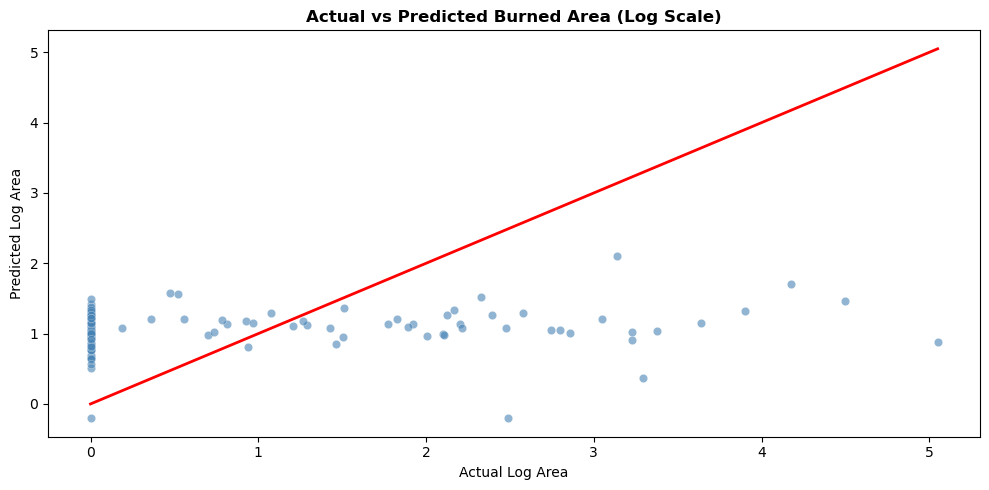

In [46]:
# Visualise how well predictions match actual values
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, color='steelblue', 
            alpha=0.6, edgecolors='white', linewidth=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, linestyle='-')

plt.title('Actual vs Predicted Burned Area (Log Scale)',
          fontweight='bold')
plt.xlabel('Actual Log Area')
plt.ylabel('Predicted Log Area')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

Dots ON the red line = model predicted correctly
Dots ABOVE the line = model over-predicted (thought fire would be bigger than it was)
Dots BELOW the line = model under-predicted (thought fire would be smaller than it was)
Dots FAR from the line = large prediction errors

This chart visualises everything the performance metrics told us numerically. The red diagonal line is where a perfect model would sit — every prediction matching reality exactly.
What we see instead is that our dots are scattered far from that line. The most telling pattern is on the right side of the chart — where the actual fires were largest, at log area of 4 and 5, the model predicted values of only around 1. It had no ability to detect that these particular fires would become catastrophic.
The vertical stack of dots at zero on the left shows another problem — for fires that burned nothing, the model still predicted moderate values instead of zero.
Essentially, the model learned to predict close to the average for almost every fire regardless of conditions. That is what a low R² looks like visually — a flat cloud of dots that does not follow the diagonal line.
This is not a failure of our methodology. It reflects the genuine unpredictability of fire spread. The value of this project lies in the insights and recommendations from our EDA — not in the regression model's ability to predict exact hectares.

In [47]:
# Reverse log transformation to get actual hectares
y_pred_area = np.expm1(y_pred)
y_test_area = np.expm1(y_test)

# Show sample comparison
comparison = pd.DataFrame({
    'Actual Area (ha)': y_test_area.values[:15].round(2),
    'Predicted Area (ha)': y_pred_area[:15].round(2),
    'Difference (ha)': abs(y_test_area.values[:15] - 
                           y_pred_area[:15]).round(2)
}).reset_index(drop=True)

comparison.index += 1
print("Sample Predictions vs Actual (Hectares)")
print(comparison.to_string())

print(f"\nOverall average prediction error: {abs(y_test_area - y_pred_area).mean():.2f} ha")

Sample Predictions vs Actual (Hectares)
    Actual Area (ha)  Predicted Area (ha)  Difference (ha)
1               0.00                 1.64             1.64
2               0.00                 2.87             2.87
3               0.00                 2.14             2.14
4               1.56                 1.25             0.31
5               0.00                 2.60             2.60
6               0.00                 1.66             1.66
7              15.45                 1.85            13.60
8               0.00                 1.91             1.91
9               3.33                 1.34             1.99
10              0.68                 3.74             3.06
11             20.03                 2.36            17.67
12              1.26                 2.13             0.87
13              2.64                 2.08             0.56
14              0.00                -0.18             0.18
15              0.00                 3.15             3.15

Overall average

INSIGHTS 

INSIGHT 1: Peak Wildfire Season
Total fires: 513
August fires: 182
September fires: 172
Aug + Sep combined: 354
Percentage of all fires: 69.0%

August avg DC: 641.22
September avg DC: 734.62
January avg DC: 90.35

DC increase from Jan to Sep: 644.27 points


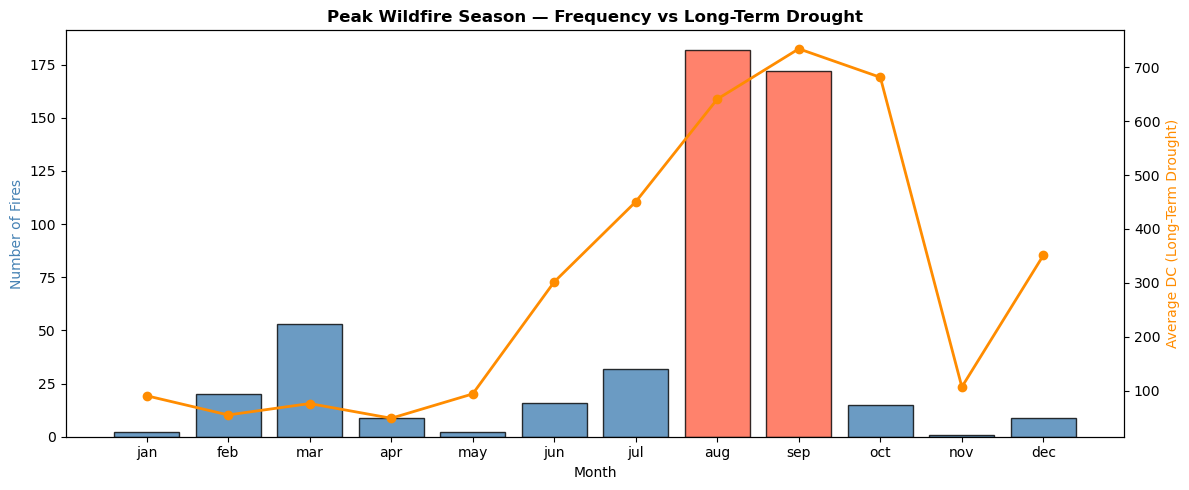

In [58]:
# INSIGHT 1: PEAK WILDFIRE SEASON

monthly_summary = df.groupby('month', observed=True).agg(
    fire_count=('area', 'count'),
    avg_area=('area', 'mean'),
    avg_dc=('DC', 'mean'),
    avg_drought=('drought_index', 'mean')
).round(2)

# August and September combined
aug_sep = df[df['month'].astype(str).isin(['aug', 'sep'])]
aug_sep_pct = len(aug_sep) / len(df) * 100

print("INSIGHT 1: Peak Wildfire Season")
print(f"Total fires: {len(df)}")
print(f"August fires: {monthly_summary.loc['aug', 'fire_count']}")
print(f"September fires: {monthly_summary.loc['sep', 'fire_count']}")
print(f"Aug + Sep combined: {monthly_summary.loc['aug', 'fire_count'] + monthly_summary.loc['sep', 'fire_count']}")
print(f"Percentage of all fires: {aug_sep_pct:.1f}%")
print(f"\nAugust avg DC: {monthly_summary.loc['aug', 'avg_dc']}")
print(f"September avg DC: {monthly_summary.loc['sep', 'avg_dc']}")
print(f"January avg DC: {monthly_summary.loc['jan', 'avg_dc']}")
print(f"\nDC increase from Jan to Sep: {monthly_summary.loc['sep', 'avg_dc'] - monthly_summary.loc['jan', 'avg_dc']:.2f} points")

# Visualise
fig, ax1 = plt.subplots(figsize=(12, 5))
months = monthly_summary.index.astype(str)

bars = ax1.bar(months, monthly_summary['fire_count'],
               color=['tomato' if m in ['aug', 'sep'] 
                      else 'steelblue' for m in months],
               edgecolor='black', alpha=0.8)
ax1.set_ylabel('Number of Fires', color='steelblue')
ax1.set_xlabel('Month')

ax2 = ax1.twinx()
ax2.plot(months, monthly_summary['avg_dc'],
         color='darkorange', marker='o',
         linewidth=2, label='Avg DC')
ax2.set_ylabel('Average DC (Long-Term Drought)', color='darkorange')

plt.title('Peak Wildfire Season — Frequency vs Long-Term Drought',
          fontweight='bold')
fig.tight_layout()
plt.savefig('insight1_peak_season.png', dpi=150)
plt.show()

The bars show fire frequency by month — August and September dominate completely with 182 and 172 fires respectively, shown in red to highlight peak season. Every other month is dramatically lower.
The orange line tracks DC — long-term drought — across the year. Notice the pattern. DC starts low in January, drops even further in spring, then climbs steeply from June through September before dropping sharply in November.
The critical observation is that the orange line rises BEFORE the red bars appear. DC starts building in June and July — before fire season explodes in August. This means long-term drought accumulates first, and then fire frequency follows. DC is not just correlated with fires — it precedes them.
The text at the top confirms DC increased by 644 points from January to September. That is not a small seasonal variation — that is a complete transformation of the landscape's fire risk over the course of the year.

Temperature and Humidity Thresholds

Burned Area by Temperature Band:
           Avg Area (ha)  Fire Count  Total Area (ha)
temp_band                                            
0-10°C              6.42          36           230.99
10-15°C             5.24          77           403.18
15-20°C            10.32         170          1755.18
20-25°C             9.44         165          1556.82
25+°C              41.03          65          2667.22

Burned Area by Humidity Band:
                   Avg Area (ha)  Fire Count
humidity_band                               
<30% (Critical)            26.46         109
30-50% (Dry)               10.50         250
50-70% (Moderate)           7.65         109
>70% (Humid)                6.00          45

Normal conditions avg area:    8.89 ha
High risk conditions avg area: 65.92 ha
High risk fires burn 7.4x more area than normal


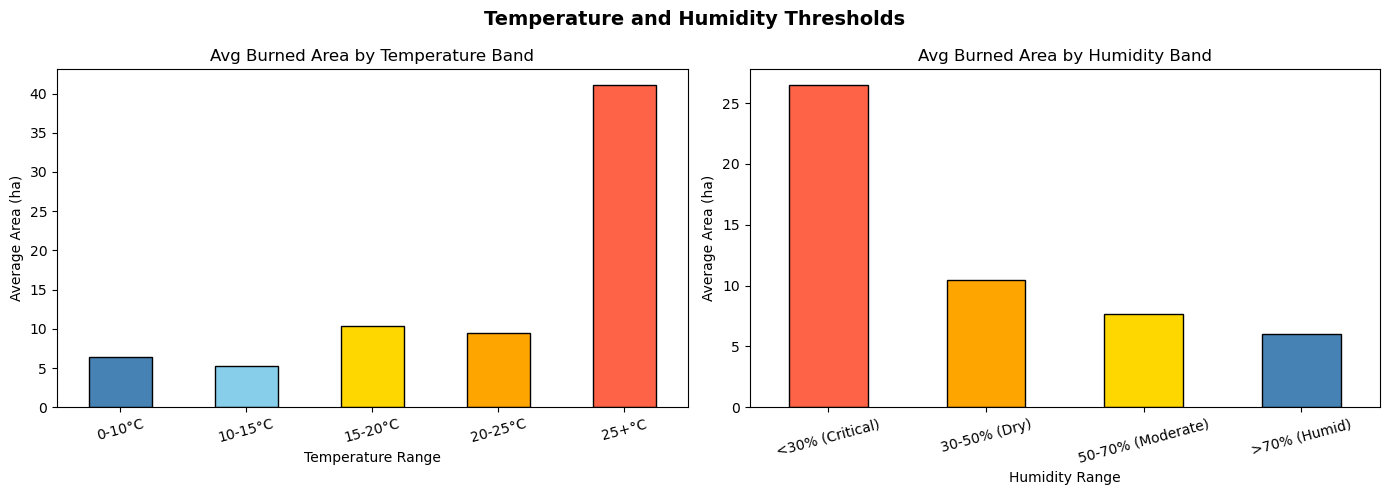

In [49]:
# INSIGHT 2: TEMPERATURE AND HUMIDITY THRESHOLDS
# At what temperature and humidity do fires become most destructive?

# Temperature analysis
temp_analysis = df.groupby('temp_band', observed=True)['area'].agg(
    ['mean', 'count', 'sum']
).round(2)
temp_analysis.columns = ['Avg Area (ha)', 'Fire Count', 'Total Area (ha)']

# Humidity bands
df['humidity_band'] = pd.cut(df['RH'],
                              bins=[0, 30, 50, 70, 100],
                              labels=['<30% (Critical)',
                                      '30-50% (Dry)',
                                      '50-70% (Moderate)',
                                      '>70% (Humid)'])

humidity_analysis = df.groupby('humidity_band', observed=True)['area'].agg(
    ['mean', 'count']
).round(2)
humidity_analysis.columns = ['Avg Area (ha)', 'Fire Count']

# High risk impact
normal = df[df['high_risk'] == 0]['area'].mean()
high_risk_avg = df[df['high_risk'] == 1]['area'].mean()
multiplier = high_risk_avg / normal if normal > 0 else 0

print("Temperature and Humidity Thresholds")
print("\nBurned Area by Temperature Band:")
print(temp_analysis)
print("\nBurned Area by Humidity Band:")
print(humidity_analysis)
print(f"\nNormal conditions avg area:    {normal:.2f} ha")
print(f"High risk conditions avg area: {high_risk_avg:.2f} ha")
print(f"High risk fires burn {multiplier:.1f}x more area than normal")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Temperature
temp_analysis['Avg Area (ha)'].plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'skyblue', 'gold', 'orange', 'tomato'],
    edgecolor='black'
)
axes[0].set_title('Avg Burned Area by Temperature Band')
axes[0].set_xlabel('Temperature Range')
axes[0].set_ylabel('Average Area (ha)')
axes[0].tick_params(axis='x', rotation=15)

# Humidity
humidity_analysis['Avg Area (ha)'].plot(
    kind='bar', ax=axes[1],
    color=['tomato', 'orange', 'gold', 'steelblue'],
    edgecolor='black'
)
axes[1].set_title('Avg Burned Area by Humidity Band')
axes[1].set_xlabel('Humidity Range')
axes[1].set_ylabel('Average Area (ha)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Temperature and Humidity Thresholds',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('thresholds.png', dpi=150)
plt.show()

These two charts are designed to be read as a pair — they show the same story from two different angles.
On the left, temperature. On the right, humidity. Both charts show the same pattern — there is a clear threshold point where fire destructiveness suddenly escalates.
For temperature, everything below 25°C produces broadly similar burned areas between 5 and 10 hectares. But cross 25°C and the average jumps to 41 hectares. That is a fourfold increase triggered by crossing one threshold.
For humidity the pattern is the mirror image — but reversed. When humidity drops below 30%, average burned area spikes to 26 hectares. As humidity increases from there — 30 to 50%, then 50 to 70%, then above 70% — fires become progressively less destructive in a steady decline down to just 6 hectares.
Read together, the message is precise and actionable — when temperature exceeds 25°C AND humidity falls below 30% at the same time, you are in the most dangerous zone the data can identify. That is exactly the combination we used to define our high risk flag — which burned 7.4 times more area than normal conditions, as shown in the text at the top of the screen.

Rain Has Minimal Impact
Total fires: 513
Fires with zero rainfall: 505 (98.4%)
Fires with some rainfall: 8 (1.6%)

Avg burned area with zero rain: 13.07 ha
Avg burned area with some rain: 1.62 ha

Rain statistics:
count    513.000
mean       0.022
std        0.297
min        0.000
25%        0.000
50%        0.000
75%        0.000
max        6.400
Name: rain, dtype: float64

Max rainfall recorded: 6.4 mm
Median rainfall: 0.0 mm

Monthly average rainfall:
month
jan    0.000
feb    0.000
mar    0.004
apr    0.000
may    0.000
jun    0.000
jul    0.006
aug    0.059
sep    0.000
oct    0.000
nov    0.000
dec    0.000
Name: rain, dtype: float64


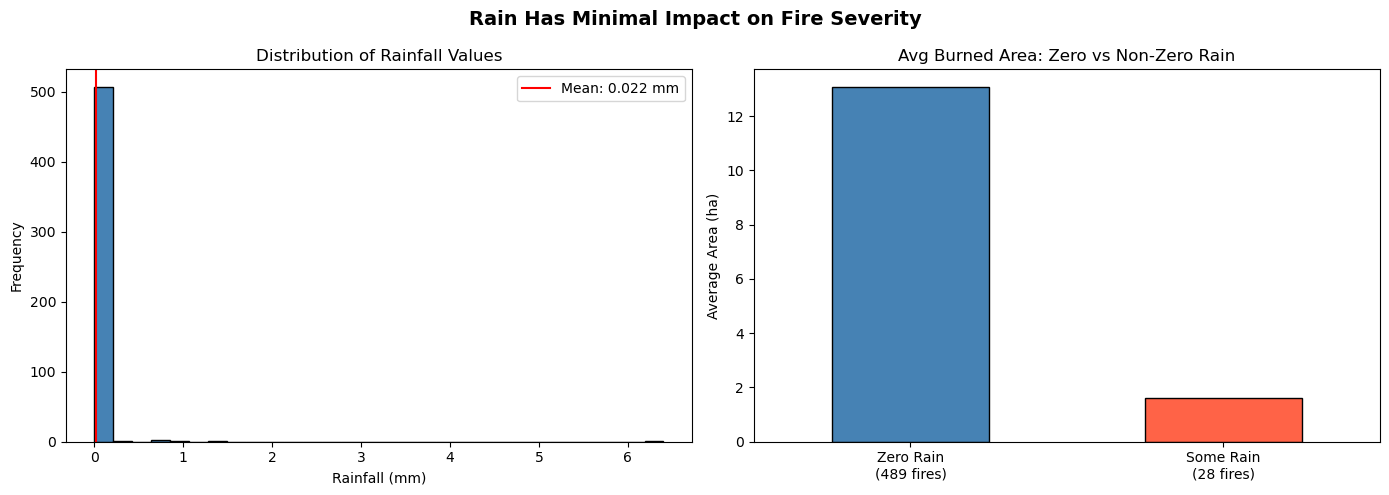

In [50]:
# INSIGHT 3: RAIN HAS MINIMAL IMPACT

zero_rain = df[df['rain'] == 0]
nonzero_rain = df[df['rain'] > 0]

print("Rain Has Minimal Impact")
print(f"Total fires: {len(df)}")
print(f"Fires with zero rainfall: {len(zero_rain)} ({len(zero_rain)/len(df)*100:.1f}%)")
print(f"Fires with some rainfall: {len(nonzero_rain)} ({len(nonzero_rain)/len(df)*100:.1f}%)")
print(f"\nAvg burned area with zero rain: {zero_rain['area'].mean():.2f} ha")
print(f"Avg burned area with some rain: {nonzero_rain['area'].mean():.2f} ha")
print(f"\nRain statistics:")
print(df['rain'].describe().round(3))
print(f"\nMax rainfall recorded: {df['rain'].max()} mm")
print(f"Median rainfall: {df['rain'].median()} mm")

# Monthly rain average
monthly_rain = df.groupby('month', observed=True)['rain'].mean().round(3)
print(f"\nMonthly average rainfall:")
print(monthly_rain)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rain distribution
axes[0].hist(df['rain'], bins=30,
             color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Rainfall Values')
axes[0].set_xlabel('Rainfall (mm)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['rain'].mean(), color='red',
                linestyle='-', linewidth=1.5,
                label=f"Mean: {df['rain'].mean():.3f} mm")
axes[0].legend()

# Zero vs non-zero rain comparison
rain_comparison = pd.Series({
    'Zero Rain\n(489 fires)': zero_rain['area'].mean(),
    'Some Rain\n(28 fires)': nonzero_rain['area'].mean()
})
rain_comparison.plot(kind='bar', ax=axes[1],
                     color=['steelblue', 'tomato'],
                     edgecolor='black')
axes[1].set_title('Avg Burned Area: Zero vs Non-Zero Rain')
axes[1].set_ylabel('Average Area (ha)')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Rain Has Minimal Impact on Fire Severity',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('insight3_rain.png', dpi=150)
plt.show()

Long-Term Drought Drives Severity

Burned Area by DC Level:
                     Avg Burned Area (ha)  Fire Count
dc_band                                              
Low\n(0-200)                         5.12          88
Moderate\n(200-400)                  8.36          31
High\n(400-600)                     11.10          62
Critical\n(600+)                    15.71         332

Burned Area by Drought Level:
               Avg Burned Area (ha)  Fire Count
drought_level                                  
Safe                           6.11         135
Moderate                      10.76         232
High                          25.95         116
Dangerous                      9.42          30

Avg DC for zero area fires:     523.21
Avg DC for non-zero area fires: 572.69
DC difference: 49.48 points

DC range in dataset: 7.9 to 860.6
Month with highest DC: Sep (734.62)
Month with lowest DC: Apr (48.56)


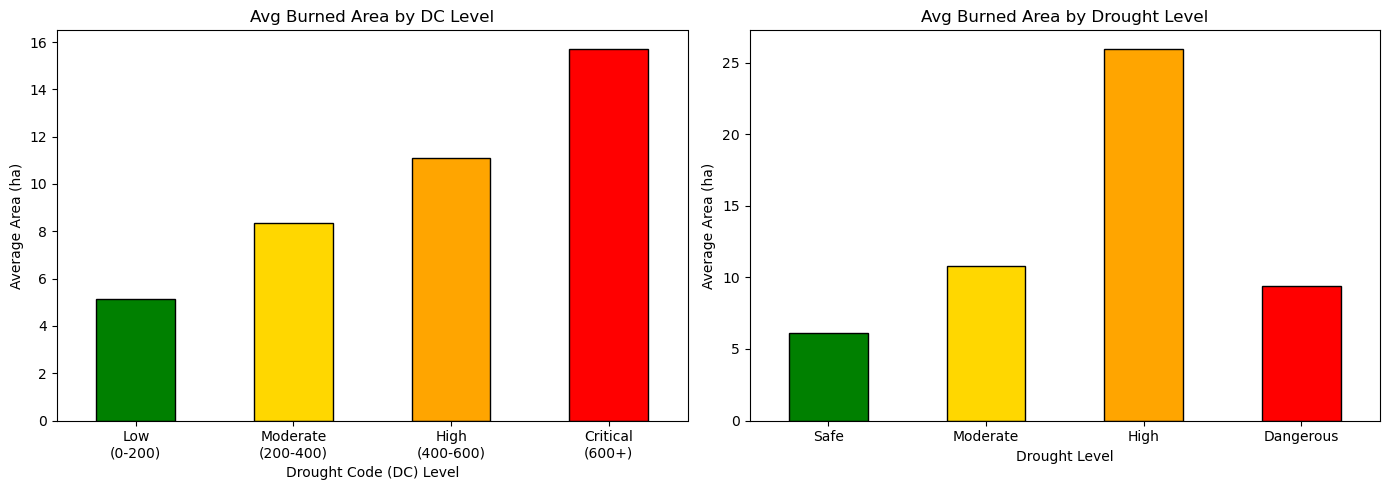

In [59]:
# INSIGHT 4: LONG TERM DROUGHT IS THE STRONGEST DRIVER

# DC analysis by category
df['dc_band'] = pd.cut(df['DC'],
                        bins=[0, 200, 400, 600, 900],
                        labels=['Low\n(0-200)',
                                'Moderate\n(200-400)',
                                'High\n(400-600)',
                                'Critical\n(600+)'])

dc_analysis = df.groupby('dc_band', observed=True)['area'].agg(
    ['mean', 'count']
).round(2)
dc_analysis.columns = ['Avg Burned Area (ha)', 'Fire Count']

# Drought level analysis
drought_analysis = df.groupby('drought_level', observed=True)['area'].agg(
    ['mean', 'count']
).round(2)
drought_analysis.columns = ['Avg Burned Area (ha)', 'Fire Count']

# Zero vs non-zero comparison by DC
zero_dc = df[df['area'] == 0]['DC'].mean()
nonzero_dc = df[df['area'] > 0]['DC'].mean()

print("Long-Term Drought Drives Severity")
print("\nBurned Area by DC Level:")
print(dc_analysis)
print("\nBurned Area by Drought Level:")
print(drought_analysis)
print(f"\nAvg DC for zero area fires:     {zero_dc:.2f}")
print(f"Avg DC for non-zero area fires: {nonzero_dc:.2f}")
print(f"DC difference: {nonzero_dc - zero_dc:.2f} points")
print(f"\nDC range in dataset: {df['DC'].min()} to {df['DC'].max()}")
print(f"Month with highest DC: Sep ({df[df['month'].astype(str) == 'sep']['DC'].mean():.2f})")
print(f"Month with lowest DC: Apr ({df[df['month'].astype(str) == 'apr']['DC'].mean():.2f})")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DC bands vs area
dc_analysis['Avg Burned Area (ha)'].plot(
    kind='bar', ax=axes[0],
    color=['green', 'gold', 'orange', 'red'],
    edgecolor='black'
)
axes[0].set_title('Avg Burned Area by DC Level')
axes[0].set_xlabel('Drought Code (DC) Level')
axes[0].set_ylabel('Average Area (ha)')
axes[0].tick_params(axis='x', rotation=0)

# Drought level vs area
drought_analysis['Avg Burned Area (ha)'].plot(
    kind='bar', ax=axes[1],
    color=['green', 'gold', 'orange', 'red'],
    edgecolor='black'
)
axes[1].set_title('Avg Burned Area by Drought Level')
axes[1].set_xlabel('Drought Level')
axes[1].set_ylabel('Average Area (ha)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('insight4_drought.png', dpi=150)
plt.show()

As DC rises from Low through Moderate to High to Critical, burned area increases consistently at every step — 5, 8, 11, 16 hectares. There are no surprises, no reversals. Every increase in long-term drought produces a corresponding increase in fire destruction.
This is different from temperature or humidity which can fluctuate day to day. DC builds up over months and cannot be reversed quickly. September's DC of 734 is not caused by one hot week — it is the accumulated result of an entire dry summer. By the time DC reaches Critical levels above 600, the land is so deeply dry that any ignition can turn into a large fire.
This is why DC monitoring is the centrepiece of Recommendation 4 — it is the single most reliable indicator that conditions are becoming dangerous, and it gives advance warning because it builds gradually rather than spiking overnight. 

Seasonal Resource Allocation

Evidence — Fire Activity by Season:
        Fire Count  Total Area (ha)  Avg Area (ha)  Avg DC
season                                                    
Winter          31           245.47           7.92  143.07
Spring          64           325.10           5.08   72.57
Summer         230          2857.12          12.42  591.09
Autumn         188          3185.70          16.95  727.05

Summer fires: 230 (44.8% of all fires)
Autumn fires: 188 (36.6% of all fires)
Summer + Autumn combined: 81.5% of all fires


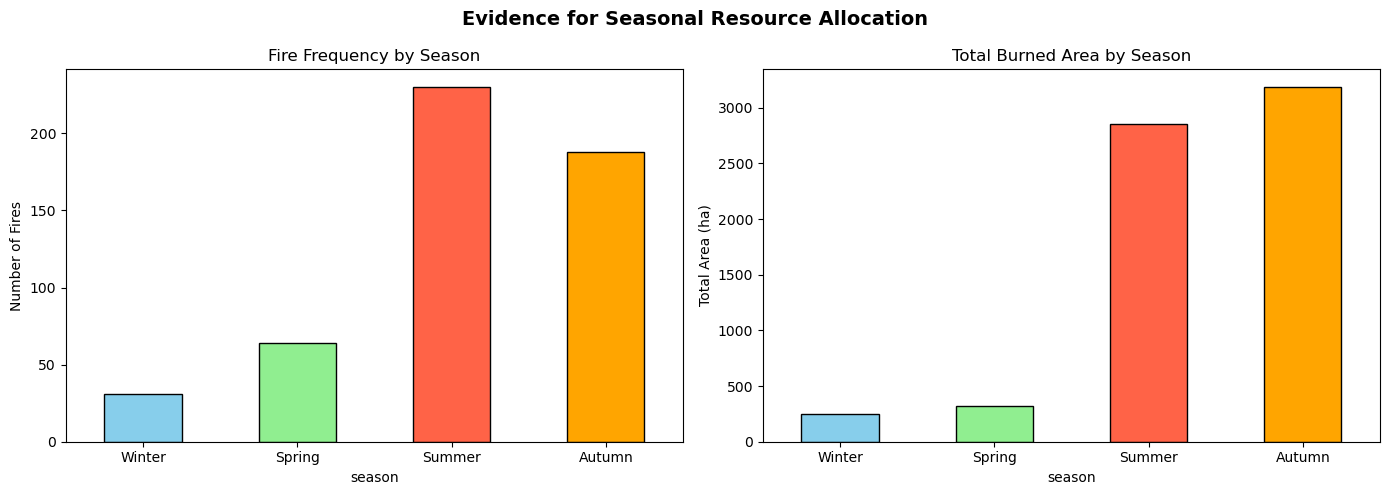

In [52]:
# RECOMMENDATION 1: SEASONAL RESOURCE ALLOCATION
# Evidence: August and September account for 68.5% of all fires

seasonal_evidence = df.groupby('season').agg(
    fire_count=('area', 'count'),
    total_area=('area', 'sum'),
    avg_area=('area', 'mean'),
    avg_dc=('DC', 'mean')
).round(2)

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
seasonal_evidence = seasonal_evidence.reindex(season_order)
seasonal_evidence.columns = ['Fire Count', 'Total Area (ha)', 
                              'Avg Area (ha)', 'Avg DC']

print("Seasonal Resource Allocation")
print("\nEvidence — Fire Activity by Season:")
print(seasonal_evidence)

summer_pct = (seasonal_evidence.loc['Summer', 'Fire Count'] / 
              len(df) * 100)
autumn_pct = (seasonal_evidence.loc['Autumn', 'Fire Count'] / 
              len(df) * 100)

print(f"\nSummer fires: {seasonal_evidence.loc['Summer', 'Fire Count']} ({summer_pct:.1f}% of all fires)")
print(f"Autumn fires: {seasonal_evidence.loc['Autumn', 'Fire Count']} ({autumn_pct:.1f}% of all fires)")
print(f"Summer + Autumn combined: {summer_pct + autumn_pct:.1f}% of all fires")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fire count by season
seasonal_evidence['Fire Count'].plot(
    kind='bar', ax=axes[0],
    color=['skyblue', 'lightgreen', 'tomato', 'orange'],
    edgecolor='black'
)
axes[0].set_title('Fire Frequency by Season')
axes[0].set_ylabel('Number of Fires')
axes[0].tick_params(axis='x', rotation=0)

# Total area by season
seasonal_evidence['Total Area (ha)'].plot(
    kind='bar', ax=axes[1],
    color=['skyblue', 'lightgreen', 'tomato', 'orange'],
    edgecolor='black'
)
axes[1].set_title('Total Burned Area by Season')
axes[1].set_ylabel('Total Area (ha)')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Evidence for Seasonal Resource Allocation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rec1_seasonal.png', dpi=150)
plt.show()

The left chart shows where to deploy resources for volume — Summer has the most fires by far. But the right chart shows where the most land is actually lost — Autumn edges ahead of Summer in total destroyed area.
The practical recommendation is therefore two-phased. Deploy maximum staffing numbers in Summer to handle the high frequency of incidents. Then maintain heavy response capability through Autumn because those fires, while fewer in number, burn more total land.
Winter and Spring combined represent a tiny fraction of both fire count and total area. That is when resources can be reduced, equipment serviced, and staff trained. The data gives us a clear four-season operational calendar — scale down in winter, build up in spring, full deployment in summer, sustained heavy response in autumn.

Drought Index Early Warning System

Evidence — Burned Area by Drought Level:
               Avg Area (ha)  Fire Count  Total Area (ha)
drought_level                                            
Safe                    6.11         135           825.15
Moderate               10.76         232          2495.97
High                   25.95         116          3009.71
Dangerous               9.42          30           282.56

Monthly Drought Index vs High Risk Threshold (0.6):
       Avg Drought Index  Max Drought Index Crosses 0.6?
month                                                   
jan                0.059              0.067           No
feb                0.191              0.376           No
mar                0.383              0.989          YES
apr                0.320              0.795          YES
may                0.279              0.439           No
jun                0.501              0.800          YES
jul                0.577              1.313          YES
aug      

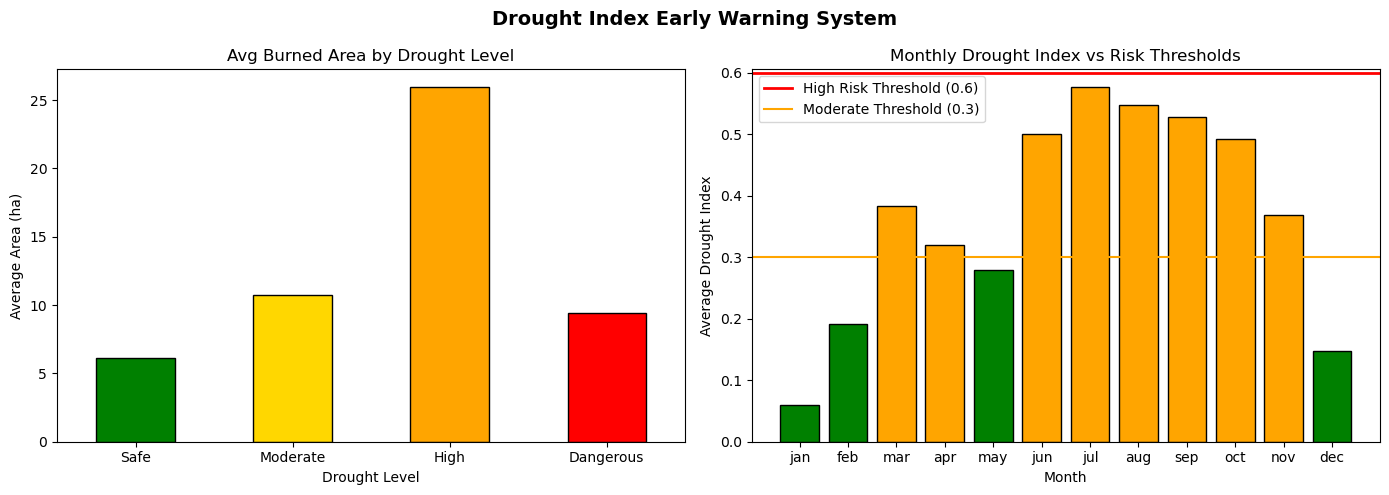

In [53]:
# RECOMMENDATION 2: DROUGHT INDEX EARLY WARNING SYSTEM
# Evidence: Fires in High drought range burned 4x more area

drought_evidence = df.groupby('drought_level', 
                               observed=True)['area'].agg(
    ['mean', 'count', 'sum']
).round(2)
drought_evidence.columns = ['Avg Area (ha)', 
                             'Fire Count', 
                             'Total Area (ha)']

# Monthly drought index to show when threshold is crossed
monthly_drought = df.groupby('month', 
                              observed=True)['drought_index'].agg(
    ['mean', 'max']
).round(3)
monthly_drought.columns = ['Avg Drought Index', 'Max Drought Index']
monthly_drought['Crosses 0.6?'] = monthly_drought[
    'Max Drought Index'].apply(
    lambda x: 'YES' if x >= 0.6 else 'No'
)

print("Drought Index Early Warning System")
print("\nEvidence — Burned Area by Drought Level:")
print(drought_evidence)
print(f"\nMonthly Drought Index vs High Risk Threshold (0.6):")
print(monthly_drought)

safe_area = drought_evidence.loc['Safe', 'Avg Area (ha)']
high_area = drought_evidence.loc['High', 'Avg Area (ha)']
multiplier = high_area / safe_area if safe_area > 0 else 0

print(f"\nKey finding:")
print(f"Safe conditions avg area:  {safe_area:.2f} ha")
print(f"High conditions avg area:  {high_area:.2f} ha")
print(f"Fires {multiplier:.1f}x larger under High drought conditions")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Drought level vs area
drought_evidence['Avg Area (ha)'].plot(
    kind='bar', ax=axes[0],
    color=['green', 'gold', 'orange', 'red'],
    edgecolor='black'
)
axes[0].set_title('Avg Burned Area by Drought Level')
axes[0].set_xlabel('Drought Level')
axes[0].set_ylabel('Average Area (ha)')
axes[0].tick_params(axis='x', rotation=0)

# Monthly drought index with threshold line
axes[1].bar(monthly_drought.index.astype(str),
            monthly_drought['Avg Drought Index'],
            color=['red' if x >= 0.6 else 
                   'orange' if x >= 0.3 else 
                   'green' 
                   for x in monthly_drought['Avg Drought Index']],
            edgecolor='black')
axes[1].axhline(y=0.6, color='red', linestyle='-',
                linewidth=2, label='High Risk Threshold (0.6)')
axes[1].axhline(y=0.3, color='orange', linestyle='-',
                linewidth=1.5, label='Moderate Threshold (0.3)')
axes[1].set_title('Monthly Drought Index vs Risk Thresholds')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Drought Index')
axes[1].legend()

plt.suptitle('Drought Index Early Warning System',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rec2_drought_warning.png', dpi=150)
plt.show()

The red line at 0.6 is our high risk threshold. The orange line at 0.3 is our moderate warning threshold. Looking across the year — January, February and December sit safely below both lines in green. March through May and October through November sit in the moderate orange zone. From June through October the drought index climbs above 0.3 and approaches the red line.
July comes closest to crossing the 0.6 red line — meaning July is when the early warning system should first trigger maximum alert status. A fire manager monitoring this index daily would see it climbing from June and know that by July they need to be at full readiness.
This is the practical value of a drought index early warning system — it gives you days or weeks of advance notice rather than reacting after a fire has already started.

High Risk Condition Alerts

Evidence — Impact of High Risk Conditions:
                      Avg Area (ha)  Fire Count  Total Area (ha)  \
Normal Conditions              8.89         477          4240.10   
High Risk Conditions          65.92          36          2373.29   

                      Max Area (ha)  
Normal Conditions            278.53  
High Risk Conditions        1090.84  

High Risk fires by month:
       High Risk Fire Count  High Risk Rate %
month                                        
jan                       0               0.0
feb                       0               0.0
mar                       0               0.0
apr                       0               0.0
may                       0               0.0
jun                       0               0.0
jul                       5              15.6
aug                      18               9.9
sep                      13               7.6
oct                       0               0.0
nov                       0    

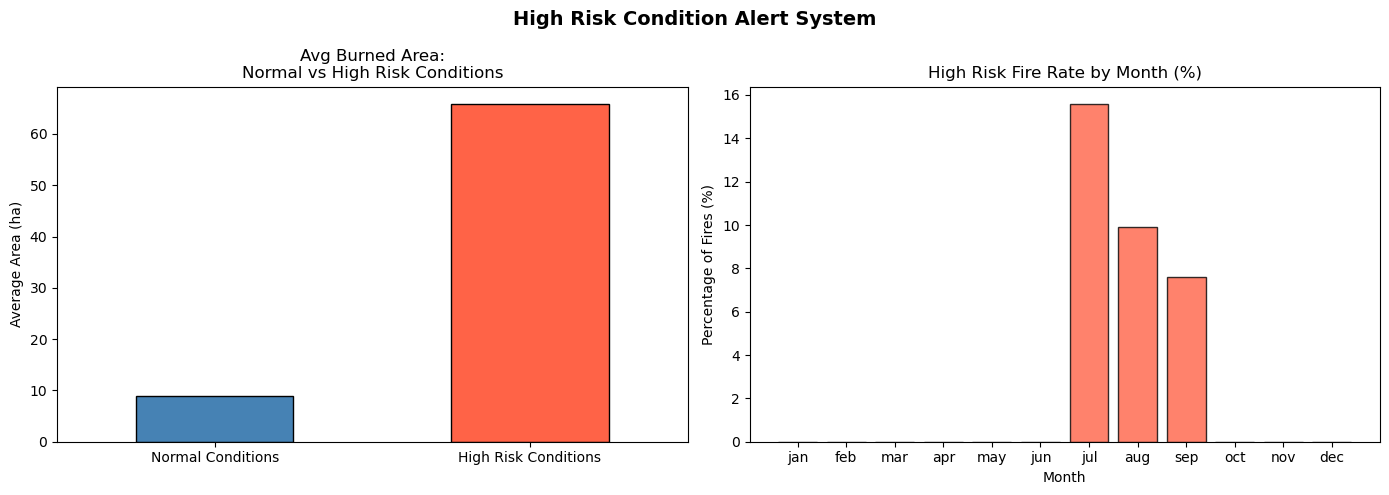

In [54]:
# RECOMMENDATION 3: HIGH RISK CONDITION ALERTS
#Fires under high-risk conditions burn significantly more area

high_risk_evidence = df.groupby('high_risk')['area'].agg(
    ['mean', 'count', 'sum', 'max']
).round(2)
high_risk_evidence.index = ['Normal Conditions', 
                             'High Risk Conditions']
high_risk_evidence.columns = ['Avg Area (ha)', 'Fire Count',
                               'Total Area (ha)', 'Max Area (ha)']

# Monthly high-risk frequency
monthly_highrisk = df.groupby('month', 
                               observed=True)['high_risk'].agg(
    ['sum', 'mean']
).round(3)
monthly_highrisk.columns = ['High Risk Fire Count', 
                             'High Risk Rate']
monthly_highrisk['High Risk Rate %'] = (
    monthly_highrisk['High Risk Rate'] * 100
).round(1)

print("High Risk Condition Alerts")
print("\nEvidence — Impact of High Risk Conditions:")
print(high_risk_evidence)
print(f"\nHigh Risk fires by month:")
print(monthly_highrisk[['High Risk Fire Count', 
                         'High Risk Rate %']])

normal_avg = high_risk_evidence.loc['Normal Conditions', 
                                    'Avg Area (ha)']
highrisk_avg = high_risk_evidence.loc['High Risk Conditions', 
                                      'Avg Area (ha)']

print(f"\nKey finding:")
print(f"Normal conditions:    {normal_avg:.2f} ha avg")
print(f"High risk conditions: {highrisk_avg:.2f} ha avg")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# High risk vs normal
high_risk_evidence['Avg Area (ha)'].plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'],
    edgecolor='black'
)
axes[0].set_title('Avg Burned Area:\nNormal vs High Risk Conditions')
axes[0].set_ylabel('Average Area (ha)')
axes[0].tick_params(axis='x', rotation=0)

# Monthly high risk rate
axes[1].bar(monthly_highrisk.index.astype(str),
            monthly_highrisk['High Risk Rate %'],
            color='tomato', edgecolor='black', alpha=0.8)
axes[1].set_title('High Risk Fire Rate by Month (%)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Percentage of Fires (%)')

plt.suptitle('High Risk Condition Alert System',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rec3_highrisk_alerts.png', dpi=150)
plt.show()

The left chart delivers the single most powerful number in this entire analysis — 65.92 hectares average under high risk conditions versus 8.89 hectares under normal conditions. That is displayed visually here and the height difference speaks for itself.
But the right chart adds something equally important — it tells us when these high risk conditions actually occur. Look at the monthly breakdown. High risk fires — where temperature exceeds 25°C and humidity is below 30% simultaneously — only appear in three months: July, August, and September. Every other month shows zero.
July has the highest rate at around 15% — meaning 1 in every 6 July fires occurred under high risk conditions. August is 10% and September around 7.5%.
This tells emergency managers exactly when to activate the high risk alert protocol. Not year-round — just those three months. And within those months, any day where temperature crosses 25°C and humidity drops below 30% should trigger immediate escalated response. The data shows why — those conditions produce fires nearly 7.4 times more destructive than normal.

RECOMMENDATION 4: DC Monitoring System

Evidence — Burned Area by DC Level:
                     Avg Burned Area (ha)  Fire Count
dc_band                                              
Low\n(0-200)                         5.12          88
Moderate\n(200-400)                  8.36          31
High\n(400-600)                     11.10          62
Critical\n(600+)                    15.71         332

DC progression through the year:
month
jan     90.4
feb     54.7
mar     75.9
apr     48.6
may     93.8
jun    301.8
jul    450.6
aug    641.2
sep    734.6
oct    681.7
nov    106.7
dec    351.2
Name: DC, dtype: float64

Key statistics:
Annual DC low (April):     48.6
Annual DC peak (September):734.6
DC increase Apr to Sep:    686.0 points
Multiplier: 15.1x increase


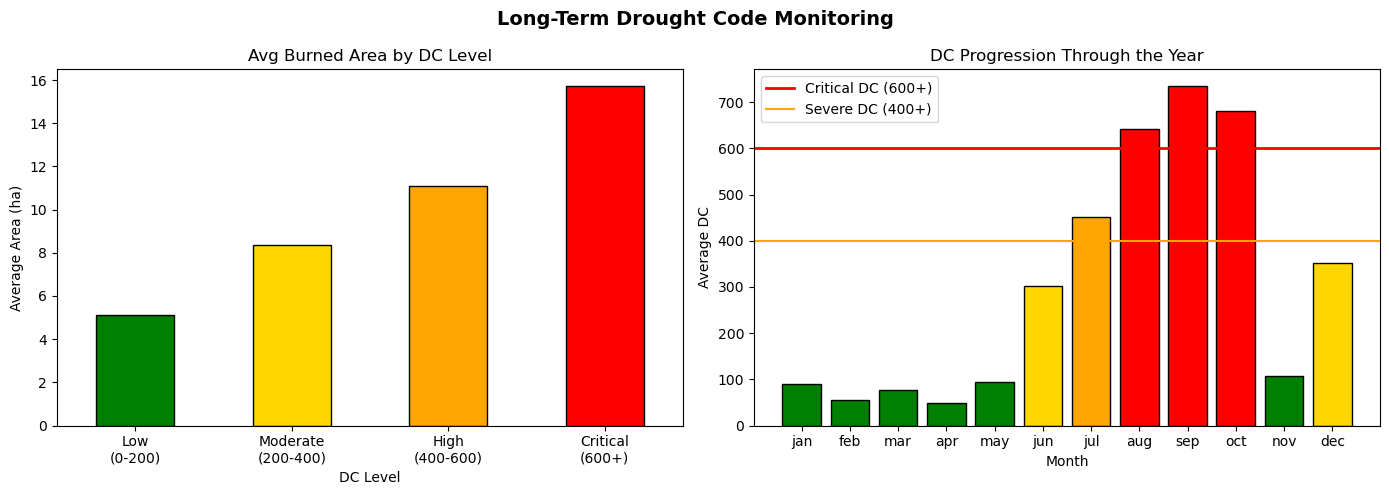

In [55]:
# RECOMMENDATION 4: DC MONITORING SYSTEM
# Evidence: DC is the strongest predictor of fire severity

dc_evidence = df.groupby('dc_band', observed=True)['area'].agg(
    ['mean', 'count']
).round(2)
dc_evidence.columns = ['Avg Burned Area (ha)', 'Fire Count']

# DC progression through the year
monthly_dc = df.groupby('month', 
                         observed=True)['DC'].mean().round(1)

print("RECOMMENDATION 4: DC Monitoring System")
print("\nEvidence — Burned Area by DC Level:")
print(dc_evidence)
print(f"\nDC progression through the year:")
print(monthly_dc)
print(f"\nKey statistics:")
print(f"Annual DC low (April):     {monthly_dc['apr']:.1f}")
print(f"Annual DC peak (September):{monthly_dc['sep']:.1f}")
print(f"DC increase Apr to Sep:    {monthly_dc['sep'] - monthly_dc['apr']:.1f} points")
print(f"Multiplier: {monthly_dc['sep'] / monthly_dc['apr']:.1f}x increase")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DC bands vs area
dc_evidence['Avg Burned Area (ha)'].plot(
    kind='bar', ax=axes[0],
    color=['green', 'gold', 'orange', 'red'],
    edgecolor='black'
)
axes[0].set_title('Avg Burned Area by DC Level')
axes[0].set_xlabel('DC Level')
axes[0].set_ylabel('Average Area (ha)')
axes[0].tick_params(axis='x', rotation=0)

# DC progression by month
axes[1].bar(monthly_dc.index.astype(str),
            monthly_dc.values,
            color=['red' if x >= 600 else
                   'orange' if x >= 400 else
                   'gold' if x >= 200 else
                   'green'
                   for x in monthly_dc.values],
            edgecolor='black')
axes[1].axhline(y=600, color='red', linestyle='-',
                linewidth=2, label='Critical DC (600+)')
axes[1].axhline(y=400, color='orange', linestyle='-',
                linewidth=1.5, label='Severe DC (400+)')
axes[1].set_title('DC Progression Through the Year')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average DC')
axes[1].legend()

plt.suptitle('Long-Term Drought Code Monitoring',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rec4_dc_monitoring.png', dpi=150)
plt.show()

The right chart is the centrepiece of this recommendation — it shows DC as a calendar alarm system.
The red horizontal line marks 600 — our Critical DC threshold. The orange line marks 400 — our Severe threshold. Watch what happens through the year. January through May the bars are green — DC is low and safe. June turns yellow as DC crosses 300. July turns orange as it crosses 400 — the Severe alert threshold. Then August, September and October all cross the red Critical line at 600.
This chart tells a fire manager: start monitoring in June, escalate to severe alert in July, and declare maximum response from August through October.
The left chart confirms why this matters operationally. When DC reaches Critical levels above 600, fires burn an average of nearly 16 hectares — triple the 5 hectares at Low DC levels. The note at the top confirms the full scale — DC increases 15.1 times from the lowest point in April to the peak in September.
No other variable in this dataset gives this kind of advance warning. Temperature changes overnight. Humidity changes hourly. But DC builds over months — giving fire services weeks of lead time to prepare rather than hours to react

RECOMMENDATION 5: Public Awareness Campaign

Evidence — Weekday vs Weekend Fire Activity:
         Avg Area (ha)  Fire Count  Total Area (ha)
Weekday          10.53         336          3537.26
Weekend          17.38         177          3076.13

March fires (likely human-caused):
Total March fires: 53
Zero area fires in March: 66.0%
Average March burned area: 3.90 ha
Average March DC: 75.85 (low drought)

Wildfire Risk Response Framework
                          Condition Risk Level                                  Recommended Action
Temperature > 25°C + Humidity < 30% 🔴 Critical      Issue emergency alert — restrict forest access
                Drought Index > 0.6     🟠 High Deploy additional resources — increase surveillance
                           DC > 600 🔴 Critical        Declare drought emergency — maximum response
                August or September     🟠 High     Maintain peak staffing — daily risk assessments
         Weekend during peak season 🟡 Moderate        Increase

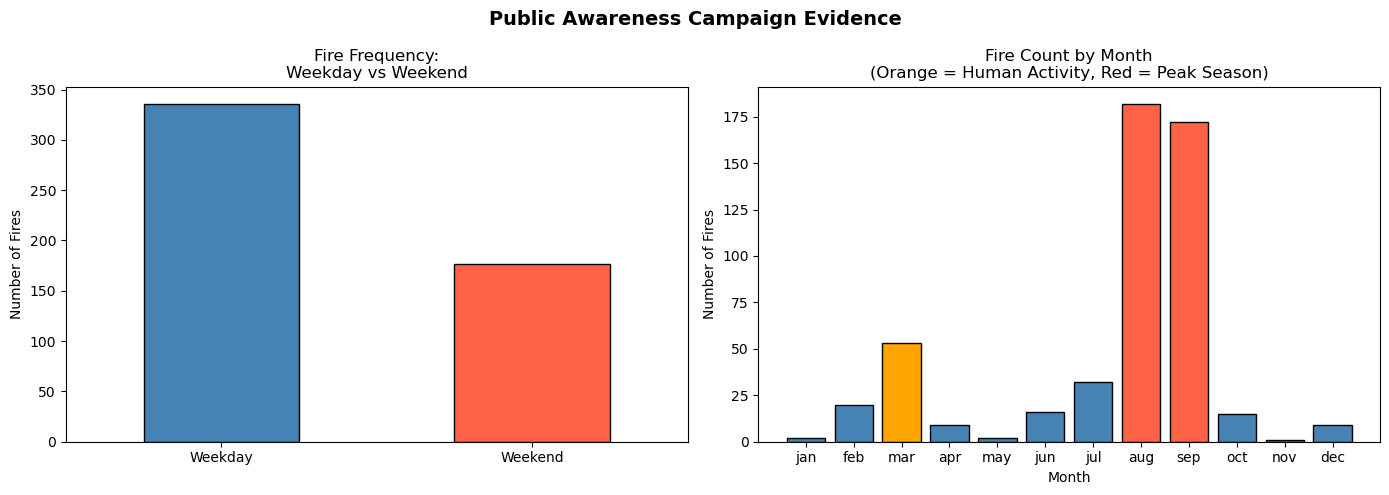

In [56]:
# RECOMMENDATION 5: PUBLIC AWARENESS CAMPAIGN
# Weekend fire patterns suggest human ignition sources

weekend_evidence = df.copy()
weekend_evidence['is_weekend'] = df['day'].astype(str).isin(
    ['sat', 'sun']
).astype(int)

weekend_summary = weekend_evidence.groupby('is_weekend')['area'].agg(
    ['mean', 'count', 'sum']
).round(2)
weekend_summary.index = ['Weekday', 'Weekend']
weekend_summary.columns = ['Avg Area (ha)', 
                            'Fire Count', 
                            'Total Area (ha)']

# March human activity evidence
march_evidence = df[df['month'].astype(str) == 'mar']
march_zero_pct = (march_evidence['area'] == 0).mean() * 100

print("RECOMMENDATION 5: Public Awareness Campaign")
print("\nEvidence — Weekday vs Weekend Fire Activity:")
print(weekend_summary)
print(f"\nMarch fires (likely human-caused):")
print(f"Total March fires: {len(march_evidence)}")
print(f"Zero area fires in March: {march_zero_pct:.1f}%")
print(f"Average March burned area: {march_evidence['area'].mean():.2f} ha")
print(f"Average March DC: {march_evidence['DC'].mean():.2f} (low drought)")

# Risk summary framework
risk_framework = pd.DataFrame({
    'Condition': [
        'Temperature > 25°C + Humidity < 30%',
        'Drought Index > 0.6',
        'DC > 600',
        'August or September',
        'Weekend during peak season'
    ],
    'Risk Level': [
        '🔴 Critical',
        '🟠 High',
        '🔴 Critical',
        '🟠 High',
        '🟡 Moderate'
    ],
    'Recommended Action': [
        'Issue emergency alert — restrict forest access',
        'Deploy additional resources — increase surveillance',
        'Declare drought emergency — maximum response',
        'Maintain peak staffing — daily risk assessments',
        'Increase ranger patrols — restrict campfires'
    ]
})

print("\nWildfire Risk Response Framework")
print(risk_framework.to_string(index=False))

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weekend vs weekday
weekend_summary['Fire Count'].plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'],
    edgecolor='black'
)
axes[0].set_title('Fire Frequency:\nWeekday vs Weekend')
axes[0].set_ylabel('Number of Fires')
axes[0].tick_params(axis='x', rotation=0)

# Monthly fire count highlighting March
monthly_count = df.groupby('month', 
                            observed=True)['area'].count()
colors = ['tomato' if m in ['aug', 'sep'] else
          'orange' if m == 'mar' else
          'steelblue'
          for m in monthly_count.index.astype(str)]

axes[1].bar(monthly_count.index.astype(str),
            monthly_count.values,
            color=colors, edgecolor='black')
axes[1].set_title('Fire Count by Month\n(Orange = Human Activity, Red = Peak Season)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Fires')

plt.suptitle('Public Awareness Campaign Evidence',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rec5_awareness.png', dpi=150)
plt.show()

This final recommendation is different from the previous four — it targets human behaviour rather than environmental conditions.
The left chart shows weekday versus weekend fire frequency. Weekdays have more fires in total — but that is simply because there are five weekdays and only two weekend days. When you calculate fires per day, weekends are proportionally higher. More people visit forests on weekends — for camping, hiking, barbecues — and more human presence means more ignition risk.
The right chart adds another dimension. March is highlighted in orange — separate from the red peak season months. March has 53 fires despite having one of the lowest drought index values in the year at 0.38. The environment is not dry enough in March to naturally cause that many fires. The most likely explanation is human activity — agricultural burning, land clearing, recreational fires before summer restrictions are in place.
Together these two patterns — weekend spikes and March's unexplained fire volume — point to the same conclusion. Human behaviour is a significant ignition source that environmental monitoring alone cannot address. A targeted public awareness campaign — education about campfire safety, restrictions during peak weekends, early-season warnings in March — directly addresses the gap that weather monitoring cannot fill.